# MC_Maze — load & explore

**Capstone, step 1: get the data into shape and understand it.**

We load the MC_Maze dataset (macaque M1 / PMd during delayed reaches; Churchland &
Shenoy labs) via [`nlb_tools`](https://github.com/neurallatents/nlb_tools) and build
a small set of **base loader functions** that turn the raw NWB file into:

- **binned spikes** (137 held-in neurons),
- **reach conditions** (per-trial reach target / direction),
- **hand velocity** (and other kinematics), trial-aligned to movement onset.

> Data source: DANDI dandiset **000128**, file
> `sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb` (~690 MB, gitignored).

> **2026-09-13 correction:** the old binning summed nonchronological rows.
> Section 2 now sorts and validates native timestamps before binning.
> Earlier saved tuning/PCA outputs below are historical, not valid current
> evidence. Section 6b contains the corrected, independently checked split-half
> experiment. Rerun earlier analyses before interpreting their old numbers.

### Prediction (written *before* the tuning plot)
**Why plot all 137 × 34:** to characterise each neuron by direction and then *group
neurons whose tuning is similar*. A random 4–5 neurons might all be silent for a
given direction; the full view lets me pick meaningful groups.

1. **Shape:** a cosine — really a Gaussian/normal bump — peaking at the neuron's
   preferred direction, if that neuron helps drive movement in that direction.
2. **How many tuned:** most of the 137 should be tuned to some direction; but with
   only 34 sampled directions, a few may not fire for any trial / look flat.
3. **Preferred directions:** non-uniformly distributed around the circle.

### Roadmap
1. **(this notebook)** load → binned spikes + reach conditions + hand velocity.
2. Understand the data (guided): sanity-check kinematics, the reach-direction
   definition, per-neuron activity.
3. Per-neuron directional **tuning curves**.
4. PCA of the population → reach-direction **decoder**.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nlb_tools.nwb_interface import NWBDataset

# --- config --------------------------------------------------------------
BIN_WIDTH_MS = 20      # spike-count bin size (native NWB resolution is 1 ms)


def _find_train_nwb():
    """Locate the MC_Maze train file whether run from ./notebooks or repo root."""
    rel = Path("data") / "000128" / "sub-Jenkins" / \
        "sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb"
    for base in (Path.cwd(), Path.cwd().parent):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(
        f"Could not find {rel} — run the download step in the README.")


TRAIN_NWB = _find_train_nwb()
print("train file:", TRAIN_NWB)
print(f"size: {TRAIN_NWB.stat().st_size / 1e6:.0f} MB")

train file: /Users/prateekkarkare/Desktop/Personal/Projects/motor-cortex-population-dynamics/data/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb
size: 691 MB


## 1. Load the raw dataset (1 ms bins)

`NWBDataset` reads the NWB file into two objects:

- **`.data`** — a continuous, time-indexed DataFrame (1 ms) with a column
  MultiIndex `(signal, channel)`: `spikes`, `heldout_spikes`, `hand_pos`,
  `hand_vel`, `cursor_pos`, `eye_pos`.
- **`.trial_info`** — one row per trial (targets, alignment events, success).

We only use the 137 held-in `spikes`; `heldout_spikes` exist for the NLB
co-smoothing benchmark and are ignored here.

In [10]:
def load_mc_maze(nwb_path):
    """Load the MC_Maze train file into an nlb_tools ``NWBDataset``.

    ``.data`` is continuous at 1 ms (spikes + hand/cursor/eye kinematics);
    ``.trial_info`` has one row per trial (targets, alignment events, success).
    """
    return NWBDataset(str(nwb_path))


dataset = load_mc_maze(TRAIN_NWB)

print("native bin width (ms):", dataset.bin_width)
print("continuous samples   :", dataset.data.shape[0], "(1 ms each)")
print("held-in neurons      :", dataset.data["spikes"].shape[1])
print("trials               :", len(dataset.trial_info))
print("signals              :", list(dataset.data.columns.get_level_values(0).unique()))

/Users/prateekkarkare/Desktop/Personal/Projects/motor-cortex-population-dynamics/.venv/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.4.0, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


native bin width (ms): 1
continuous samples   : 6952301 (1 ms each)
held-in neurons      : 137
trials               : 2295
signals              : ['cursor_pos', 'eye_pos', 'hand_pos', 'hand_vel', 'heldout_spikes', 'spikes']


## 2. Bin the spikes

Resample from 1 ms to `BIN_WIDTH_MS`. Spikes are **summed** per bin (counts);
continuous signals (hand velocity, etc.) are **averaged**. This mutates the
dataset in place — re-run the load cell to get back to 1 ms.

In [11]:
def bin_spikes(ds, bin_width_ms=BIN_WIDTH_MS):
    """Resample counts and kinematics only after validating the chronological clock.

    nlb_tools bins consecutive rows, so native timestamps must be sorted and
    regularly spaced first. Restore pandas frequency metadata only when the
    replacement index has exactly the same timestamps; never silently retime data.
    """
    if ds.bin_width == bin_width_ms:
        return ds
    n_before = ds.data.shape[0]
    if not ds.data.index.is_monotonic_increasing:
        print("Sorting native timestamps before positional spike binning.")
        ds.data = ds.data.sort_index()
    native_index = pd.timedelta_range(
        start=ds.data.index[0], periods=len(ds.data),
        freq=f"{ds.bin_width}ms", name="clock_time",
    )
    if not ds.data.index.equals(native_index):
        raise ValueError("Native timestamps are not a unique, regular clock; refusing to bin.")
    ds.data.index = native_index
    try:
        ds.resample(bin_width_ms)
    except ValueError:
        assert ds.data.shape[0] < n_before, "resample did not actually rebin"
        ds.bin_width = bin_width_ms
    binned_index = pd.timedelta_range(
        start=ds.data.index[0], periods=len(ds.data),
        freq=f"{bin_width_ms}ms", name="clock_time",
    )
    if not ds.data.index.equals(binned_index):
        raise ValueError("Binned timestamps do not match the expected clock; refusing to relabel.")
    ds.data.index = binned_index
    assert ds.bin_width == bin_width_ms
    return ds


bin_spikes(dataset, BIN_WIDTH_MS)

# sanity: median spacing of the binned index should equal the bin width
_step_ms = np.median(np.diff(dataset.data.index.total_seconds())) * 1000
print("bin width (ms):", dataset.bin_width, f"(median index step {_step_ms:.1f} ms)")
print("binned samples:", dataset.data.shape[0])
print("spikes block  :", dataset.data["spikes"].shape)

Sorting native timestamps before positional spike binning.
bin width (ms): 20 (median index step 20.0 ms)
binned samples: 347616
spikes block  : (347616, 137)


## 3. Reach conditions per trial

Each trial shows up to 3 targets (`target_pos`); `active_target` indexes the one
actually reached to. The reach **direction** is the angle of that target from the
center hold.

> In the maze task the *path* can curve around barriers, so "target direction" and
> "instantaneous hand direction" are not identical — which one counts as *reach
> direction* is a modelling choice we'll revisit before building tuning curves.
> This function surfaces the target-based angle plus the raw fields.

In [5]:
def reach_conditions(ds):
    """One row per trial describing *where the reach went*.

    The reached target is ``target_pos[active_target]``; ``reach_angle_deg`` is
    the direction of that target from center (target-based reach direction).
    """
    ti = ds.trial_info
    target_pos = ti["target_pos"].to_numpy()
    active = ti["active_target"].to_numpy()
    xy = np.array([np.asarray(target_pos[i], dtype=float)[active[i]]
                   for i in range(len(ti))])
    x, y = xy[:, 0], xy[:, 1]
    return pd.DataFrame({
        "trial_id": ti["trial_id"].to_numpy(),
        "target_x": x,
        "target_y": y,
        "reach_angle_deg": np.degrees(np.arctan2(y, x)),
        "reach_dist": np.hypot(x, y),
        "trial_type": ti["trial_type"].to_numpy(),
        "maze_id": ti["maze_id"].to_numpy(),
        "num_targets": ti["num_targets"].to_numpy(),
        "success": ti["success"].to_numpy(),
        "move_onset_time": ti["move_onset_time"].to_numpy(),
    })


conditions = reach_conditions(dataset)
print(conditions.shape)
conditions.head()

(2295, 10)


,trial_id,target_x,target_y,reach_angle_deg,reach_dist,trial_type,maze_id,num_targets,success,move_onset_time
0,0,118.0,72.0,31.390268,138.231690,25,84,3,True,0 days 00:00:01.905000
1,1,-116.0,-5.0,-177.531882,116.107709,3,3,1,True,0 days 00:00:05.280000
2,2,-82.0,-86.0,-133.636072,118.827606,22,66,1,True,0 days 00:00:08.346000
3,3,2.0,82.0,88.602819,82.024387,29,100,3,True,0 days 00:00:11.752000
4,4,27.0,82.0,71.774925,86.330759,21,65,1,True,0 days 00:00:14.507000


## 4. Trial-aligned spikes + hand velocity

`make_trial_data` cuts the continuous data into per-trial segments aligned to a
task event (here **movement onset**) within a time window. Bin edges are relative
to the alignment event, so trials become directly comparable — the form we'll use
to compute per-neuron firing rates by reach direction.

In [12]:
def make_trial_spikes(ds, align_field="move_onset_time", window_ms=(-200, 600)):
    """Trial-aligned binned data around a task event.

    Returns the nlb_tools trial DataFrame: every trial's binned spikes and
    kinematics (incl. ``hand_vel``), clipped to ``window_ms`` around
    ``align_field`` (e.g. movement onset), plus meta columns like ``trial_id``
    and ``align_time``.
    """
    return ds.make_trial_data(align_field=align_field, align_range=window_ms)


trials = make_trial_spikes(dataset)
bins_per_trial = int((600 - (-200)) / dataset.bin_width)
print("trial-aligned rows :", trials.shape[0])
print("signals (level 0)  :", list(trials.columns.get_level_values(0).unique()))
print("expected bins/trial:", bins_per_trial, f"(-200..600 ms @ {dataset.bin_width} ms)")
trials.head()

NaNs found in `self.data`. Dropping 2.05% of points to remove NaNs from `trial_data`.


trial-aligned rows : 89920
signals (level 0)  : ['align_time', 'clock_time', 'cursor_pos', 'eye_pos', 'hand_pos', 'hand_vel', 'heldout_spikes', 'margin', 'spikes', 'trial_id', 'trial_time']
expected bins/trial: 40 (-200..600 ms @ 20 ms)


align_time             clock_time cursor_pos            \
                                                           x         y   
0 -1 days +23:59:59.800000 0 days 00:00:01.720000  -1.499739 -7.629926   
1 -1 days +23:59:59.820000 0 days 00:00:01.740000  -1.499857 -7.597105   
2 -1 days +23:59:59.840000 0 days 00:00:01.760000  -1.497862 -7.612576   
3 -1 days +23:59:59.860000 0 days 00:00:01.780000  -1.500481 -7.648724   
4 -1 days +23:59:59.880000 0 days 00:00:01.800000  -1.495339 -7.611032   

      eye_pos             hand_pos             hand_vel            ... spikes  \
            x          y         x          y         x         y  ...   2861   
0  -18.223019  -0.655376 -1.522926 -42.630193  0.311218  0.161879  ...    0.0   
1  -19.047413  -1.079590 -1.509622 -42.630682  0.383868 -0.721782  ...    0.0   
2   -7.023040   0.458028 -1.518505 -42.645698 -0.848503  0.204770  ...    0.0   
3   90.972647  14.199807 -1.518529 -42.631233  0.849756 -0.485864  ...    0.0   
4  151.015360  14.063791 -1.509818 -42.708989 -0.280203 -6.327893  ...    0.0   

                                     trial_id             trial_time  
  2862 2871 2881 2911 2931 2951 2961                                  
0  2.0  0.0  0.0  0.0  0.0  0.0  1.0        0 0 days 00:00:01.720000  
1  0.0  0.0  0.0  0.0  0.0  0.0  2.0        0 0 days 00:00:01.740000  
2  0.0  0.0  0.0  0.0  1.0  0.0  0.0        0 0 days 00:00:01.760000  
3  0.0  0.0  0.0  0.0  1.0  1.0  0.0        0 0 days 00:00:01.780000  
4  0.0  0.0  1.0  0.0  0.0  0.0  0.0        0 0 days 00:00:01.800000  

[5 rows x 195 columns]

## Understanding the data first (guided)

Base loaders are in place (`load_mc_maze` → `bin_spikes` → `reach_conditions` +
`make_trial_spikes`). Before any tuning curve, we work through basic questions to
*understand* the data — starting with the visual sanity checks below.

Still to decide before tuning: how to define **reach direction** (target angle vs
hand-velocity angle) and the **firing-rate window**. _No tuning-curve code yet._

## 5. Visual sanity checks — one trial

Before any analysis, *look* at a single trial: (a) a **time-aligned overview** —
spike raster + per-neuron rate heatmap + hand/eye kinematics stacked on one shared
time axis (read neural activity straight down against behaviour) — and (b) a 2-D
**workspace diagram** (targets, barriers, cursor / hand / eye paths).

Rasters want spike-time resolution, so we keep a fresh **1 ms** copy (`ds_fine`) —
the `dataset` above was binned to 20 ms in place. First, a numeric peek at one
trial so the picture below is unambiguous (which coordinate frame is which, how
`barrier_pos` is encoded).

In [14]:
# Fresh 1 ms copy for visualisation (binning above was in place / destructive).
ds_fine = load_mc_maze(TRAIN_NWB)

EX_TRIAL = 2  # a single-target trial (num_targets == 1) is easiest to read first
row = ds_fine.trial_info[ds_fine.trial_info["trial_id"] == EX_TRIAL].iloc[0]

targets = np.asarray(row["target_pos"], dtype=float)
barriers = np.asarray(row["barrier_pos"], dtype=float)
print(f"trial {EX_TRIAL}: num_targets={row['num_targets']} active={row['active_target']} "
      f"num_barriers={row['num_barriers']}")
print("targets      :", targets.tolist())
print("active target:", targets[row["active_target"]].tolist())
print("barrier_pos rows (4 cols each):", barriers.tolist()[:3], "...")
print("events (s): target_on={:.3f} go_cue={:.3f} move_onset={:.3f} end={:.3f}".format(
    row["target_on_time"].total_seconds(), row["go_cue_time"].total_seconds(),
    row["move_onset_time"].total_seconds(), row["end_time"].total_seconds()))

# which position signal shares the target coordinate frame?
start, end = row["start_time"], row["end_time"]
for sig in ["cursor_pos", "hand_pos", "eye_pos"]:
    seg = ds_fine.data[sig].loc[start:end]
    print(f"{sig:10s} x[{seg['x'].min():8.1f},{seg['x'].max():8.1f}]  "
          f"y[{seg['y'].min():8.1f},{seg['y'].max():8.1f}]  "
          f"start=({seg['x'].iloc[0]:.1f},{seg['y'].iloc[0]:.1f}) "
          f"end=({seg['x'].iloc[-1]:.1f},{seg['y'].iloc[-1]:.1f})")

/Users/prateekkarkare/Desktop/Personal/Projects/motor-cortex-population-dynamics/.venv/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.4.0, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


trial 2: num_targets=1 active=0 num_barriers=9
targets      : [[-82.0, -86.0]]
active target: [-82.0, -86.0]
barrier_pos rows (4 cols each): [[34.0, -41.0, 86.0, 8.0], [9.0, -42.0, 33.0, 19.0], [7.0, -41.0, 48.0, 12.0]] ...
events (s): target_on=7.471 go_cue=7.969 move_onset=8.346 end=9.856
cursor_pos x[  -138.7,   152.9]  y[  -138.4,   135.3]  start=(-0.2,10.1) end=(nan,nan)
hand_pos   x[  -137.3,   152.0]  y[  -170.6,    98.5]  start=(-0.0,-25.0) end=(nan,nan)
eye_pos    x[  -357.5,   225.1]  y[  -198.1,   342.5]  start=(0.8,-9.4) end=(nan,nan)


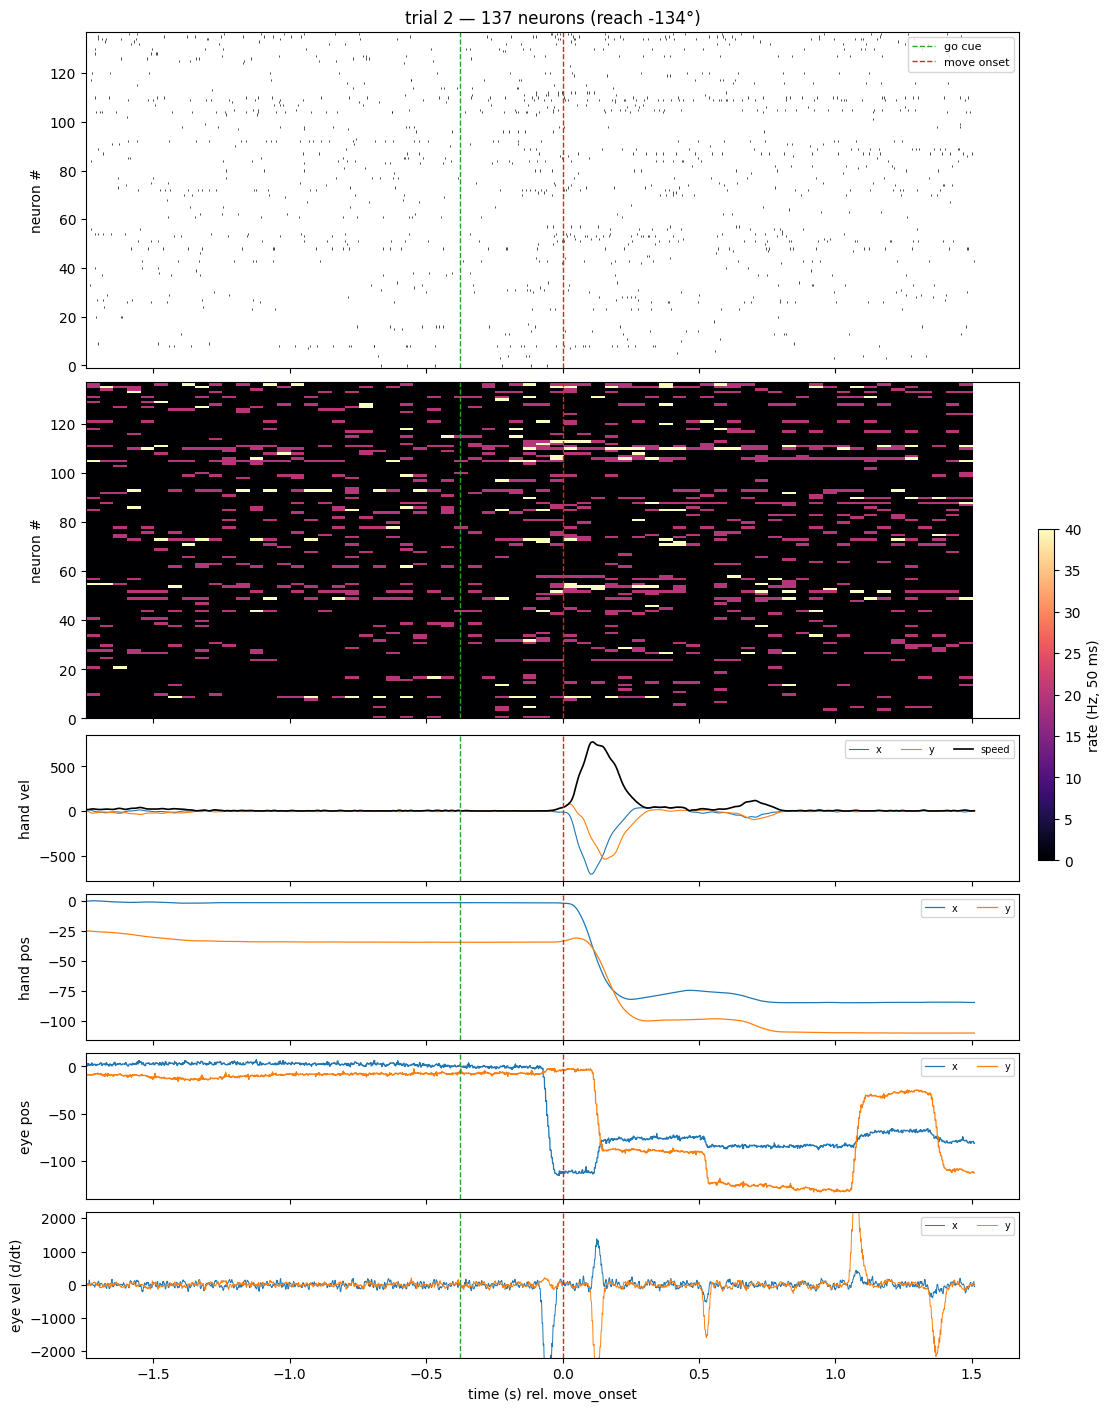

In [23]:
# --- 5a. Trial overview: raster + per-neuron rates + kinematics, shared time axis ---
def trial_window(ds, row):
    """Rows of ds.data within one trial's [start_time, end_time].

    Use a boolean mask, not .loc[start:end]: the native 1 ms index doesn't
    label-slice reliably under pandas >= 1.5 (it silently returns everything).
    """
    idx = ds.data.index
    return ds.data[(idx >= row["start_time"]) & (idx <= row["end_time"])]


def binned_rates(counts, dt_ms, win_ms):
    """Per-neuron firing rate (Hz) in simple, non-overlapping windows.

    counts: (T, N) spike counts at `dt_ms` resolution. Bins T into consecutive
    windows of `win_ms` (no overlap, no smoothing), sums within each window *per
    neuron*, then normalises to spikes/s. Returns (rate_hz (n_win, N), rows_per_window).

    Single-trial caveat: rates are quantised to multiples of 1000/win_ms Hz (one
    spike/window). Small windows (20 ms) -> 0/50/100 Hz (basically the raster);
    wider windows (50-100 ms) collect more spikes and look graded.
    """
    T, N = counts.shape
    w = max(1, int(round(win_ms / dt_ms)))               # source rows per window
    nb = T // w                                          # whole windows only
    per_win = counts[:nb * w].reshape(nb, w, N).sum(axis=1)   # spikes/window/neuron
    rate_hz = per_win / (w * dt_ms / 1000.0)             # -> per-neuron Hz
    return rate_hz, w


def plot_trial_overview(ds, trial_id, neurons=None, align="move_onset_time",
                        rate_win_ms=50):
    """Everything about one trial on a shared time axis (relative to `align`):
    (1) spike raster, (2) per-neuron rate heatmap, (3) hand velocity, (4) hand
    position, (5) eye position, (6) eye velocity (derived). Lets you eyeball
    neural activity against behaviour.

    `neurons`: None = all 137 held-in neurons, or an int for the first N.
    """
    row = ds.trial_info[ds.trial_info["trial_id"] == trial_id].iloc[0]
    seg = trial_window(ds, row)
    t = (seg.index - row[align]).total_seconds().to_numpy()

    spikes = seg["spikes"]
    cols = spikes.columns if neurons is None else spikes.columns[:neurons]
    counts = np.nan_to_num(spikes[cols].to_numpy())
    N = counts.shape[1]

    rate_hz, w = binned_rates(counts, ds.bin_width, rate_win_ms)
    centers = t[:len(rate_hz) * w].reshape(-1, w).mean(axis=1)     # window centres (s)
    dt = w * ds.bin_width / 1000.0                                 # window width (s)

    fig, axes = plt.subplots(
        6, 1, figsize=(11, 14), sharex=True,
        gridspec_kw=dict(height_ratios=[3, 3, 1.3, 1.3, 1.3, 1.3]),
        constrained_layout=True)
    ax_raster, ax_rate, ax_hv, ax_hp, ax_ep, ax_ev = axes

    # 1) spike raster
    ax_raster.eventplot([t[counts[:, i] > 0] for i in range(N)], colors="black",
                        lineoffsets=np.arange(N), linelengths=0.9, linewidths=0.5)
    tx, ty = np.asarray(row["target_pos"], dtype=float)[row["active_target"]]
    ax_raster.set(ylabel="neuron #", ylim=(-1, N),
                  title=f"trial {trial_id} — {N} neurons "
                        f"(reach {np.degrees(np.arctan2(ty, tx)):.0f}\u00b0)")

    # 2) per-neuron rate heatmap (same neuron ordering as raster)
    im = ax_rate.imshow(rate_hz.T, aspect="auto", origin="lower", cmap="magma",
                        interpolation="nearest",
                        extent=[centers[0] - dt / 2, centers[-1] + dt / 2, 0, N],
                        vmax=np.percentile(rate_hz, 99) or None)
    ax_rate.set(ylabel="neuron #")
    fig.colorbar(im, ax=list(axes), shrink=0.25, pad=0.02,
                 label=f"rate (Hz, {rate_win_ms} ms)")

    # 3) hand velocity (x, y, speed)
    ax_hv.plot(t, seg["hand_vel"]["x"], lw=0.8, label="x")
    ax_hv.plot(t, seg["hand_vel"]["y"], lw=0.8, label="y")
    ax_hv.plot(t, np.hypot(seg["hand_vel"]["x"], seg["hand_vel"]["y"]),
               color="black", lw=1.2, label="speed")
    ax_hv.set(ylabel="hand vel")
    ax_hv.legend(fontsize=7, ncol=3, loc="upper right")

    # 4) hand position (x, y)
    ax_hp.plot(t, seg["hand_pos"]["x"], lw=0.9, label="x")
    ax_hp.plot(t, seg["hand_pos"]["y"], lw=0.9, label="y")
    ax_hp.set(ylabel="hand pos")
    ax_hp.legend(fontsize=7, ncol=2, loc="upper right")

    # 5) eye position (x, y)
    ax_ep.plot(t, seg["eye_pos"]["x"], lw=0.9, label="x")
    ax_ep.plot(t, seg["eye_pos"]["y"], lw=0.9, label="y")
    ax_ep.set(ylabel="eye pos")
    ax_ep.legend(fontsize=7, ncol=2, loc="upper right")

    # 6) eye velocity: d/dt of lightly-smoothed eye position. Raw 1 ms differencing
    #    is ~pure tracker noise, so smooth ~20 ms first -> saccades = clean spikes.
    sm = max(1, int(round(20 / ds.bin_width)))
    ex = seg["eye_pos"]["x"].rolling(sm, center=True, min_periods=1).mean().to_numpy()
    ey = seg["eye_pos"]["y"].rolling(sm, center=True, min_periods=1).mean().to_numpy()
    evx, evy = np.gradient(ex, t), np.gradient(ey, t)
    ax_ev.plot(t, evx, lw=0.7, label="x")
    ax_ev.plot(t, evy, lw=0.7, label="y")
    lim = np.nanpercentile(np.abs(np.concatenate([evx, evy])), 99)  # clip saccade spikes
    if np.isfinite(lim) and lim > 0:
        ax_ev.set_ylim(-lim, lim)
    ax_ev.set(ylabel="eye vel (d/dt)",
              xlabel=f"time (s) rel. {align.replace('_time', '')}")
    ax_ev.legend(fontsize=7, ncol=2, loc="upper right")

    # event markers on every panel (labelled once, on the raster)
    for ax in axes:
        for field, color, lab in [("go_cue_time", "tab:green", "go cue"),
                                   ("move_onset_time", "tab:red", "move onset")]:
            if pd.notnull(row[field]):
                ax.axvline((row[field] - row[align]).total_seconds(), color=color,
                           ls="--", lw=1.0, label=(lab if ax is ax_raster else None))
    ax_raster.legend(loc="upper right", fontsize=8)
    return fig


plot_trial_overview(ds_fine, EX_TRIAL)
plt.show()

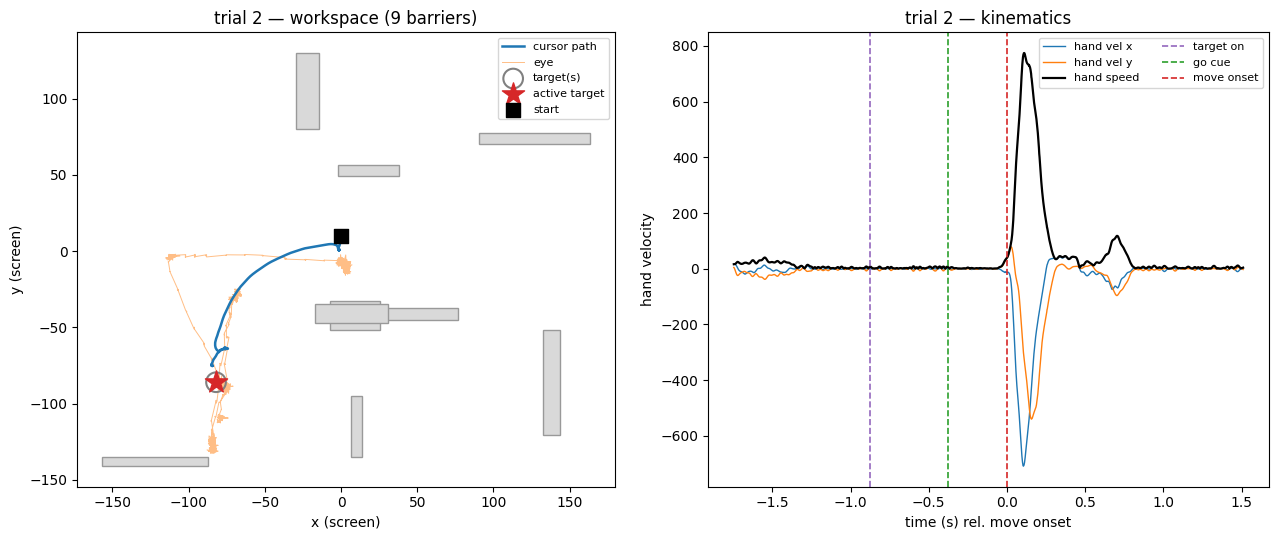

In [18]:
# --- 5b. Workspace geometry + kinematics, one trial ---
from matplotlib.patches import Rectangle


def plot_trial_geometry(ds, trial_id, barrier_is_center=True):
    """Left: workspace (targets, barriers, cursor + eye paths). Right: hand
    kinematics over time with event markers.

    `cursor_pos` shares the target coordinate frame, so it's the on-screen path;
    `hand_pos` is the physical manipulandum (y-shifted) and is shown only on the
    time axis. `barrier_pos` rows are [x, y, w, h]; `barrier_is_center` toggles
    whether (x, y) is the rectangle centre (assumed) or its lower-left corner.
    """
    row = ds.trial_info[ds.trial_info["trial_id"] == trial_id].iloc[0]
    t0 = row["move_onset_time"]
    seg = trial_window(ds, row)
    t = (seg.index - t0).total_seconds().to_numpy()

    targets = np.asarray(row["target_pos"], dtype=float)
    active = row["active_target"]
    barriers = np.asarray(row["barrier_pos"], dtype=float)
    barriers = barriers.reshape(-1, 4) if barriers.size else np.empty((0, 4))

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.5))

    # workspace
    for bx, by, bw, bh in barriers:
        ll = (bx - bw / 2, by - bh / 2) if barrier_is_center else (bx, by)
        axL.add_patch(Rectangle(ll, bw, bh, facecolor="0.85", edgecolor="0.6", zorder=1))
    cur = seg["cursor_pos"].dropna()
    axL.plot(cur["x"], cur["y"], color="tab:blue", lw=1.8, label="cursor path", zorder=4)
    eye = seg["eye_pos"].dropna()
    axL.plot(eye["x"], eye["y"], color="tab:orange", lw=0.7, alpha=0.5, label="eye", zorder=2)
    axL.scatter(targets[:, 0], targets[:, 1], s=200, facecolors="none",
                edgecolors="gray", linewidths=1.5, label="target(s)", zorder=5)
    axL.scatter(*targets[active], s=280, color="tab:red", marker="*",
                label="active target", zorder=6)
    axL.scatter(cur["x"].iloc[0], cur["y"].iloc[0], s=90, color="black",
                marker="s", label="start", zorder=6)
    axL.set(aspect="equal", xlabel="x (screen)", ylabel="y (screen)",
            title=f"trial {trial_id} — workspace ({row['num_barriers']} barriers)")
    axL.legend(fontsize=8, loc="best")

    # kinematics over time
    axR.plot(t, seg["hand_vel"]["x"], lw=1, label="hand vel x")
    axR.plot(t, seg["hand_vel"]["y"], lw=1, label="hand vel y")
    axR.plot(t, np.hypot(seg["hand_vel"]["x"], seg["hand_vel"]["y"]),
             color="black", lw=1.6, label="hand speed")
    for field, color, label in [("target_on_time", "tab:purple", "target on"),
                                 ("go_cue_time", "tab:green", "go cue"),
                                 ("move_onset_time", "tab:red", "move onset")]:
        if pd.notnull(row[field]):
            axR.axvline((row[field] - t0).total_seconds(), color=color, ls="--",
                        lw=1.2, label=label)
    axR.set(xlabel="time (s) rel. move onset", ylabel="hand velocity",
            title=f"trial {trial_id} — kinematics")
    axR.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    return fig


plot_trial_geometry(ds_fine, EX_TRIAL)
plt.show()

2295 trials | 34 unique reach angles (1 dp) | 35 unique active-target positions


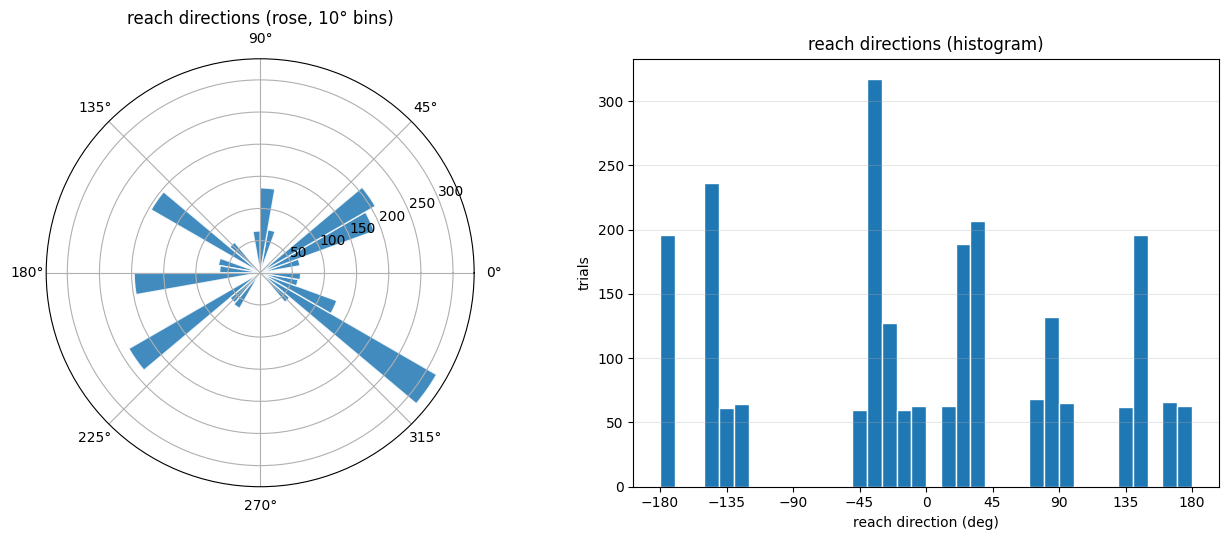

In [24]:
# --- 5c. Distribution of (static, target-based) reach directions across all trials ---
rc = reach_conditions(dataset)               # per-trial reach angle (deg), target-based
ang = rc["reach_angle_deg"].to_numpy()

n_uniq_ang = rc["reach_angle_deg"].round(1).nunique()
n_uniq_tgt = rc[["target_x", "target_y"]].drop_duplicates().shape[0]
print(f"{len(ang)} trials | {n_uniq_ang} unique reach angles (1 dp) | "
      f"{n_uniq_tgt} unique active-target positions")

fig = plt.figure(figsize=(13, 5.5))

# polar rose: the angular distribution (reach direction is circular)
ax_rose = fig.add_subplot(1, 2, 1, projection="polar")
nbins = 36
edges = np.deg2rad(np.linspace(-180, 180, nbins + 1))
counts, _ = np.histogram(np.deg2rad(ang), bins=edges)
ax_rose.bar(edges[:-1] + np.diff(edges) / 2, counts, width=np.diff(edges),
            color="tab:blue", edgecolor="white", alpha=0.85, align="center")
ax_rose.set_theta_zero_location("E")         # 0 deg = +x, matching atan2
ax_rose.set_theta_direction(1)               # counterclockwise positive
ax_rose.set_title(f"reach directions (rose, {360 // nbins}\u00b0 bins)")

# linear histogram: read exact counts per 10 deg
ax_h = fig.add_subplot(1, 2, 2)
ax_h.hist(ang, bins=np.arange(-180, 181, 10), color="tab:blue", edgecolor="white")
ax_h.set(xlabel="reach direction (deg)", ylabel="trials",
         xticks=np.arange(-180, 181, 45), title="reach directions (histogram)")
ax_h.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

## 6. Directional tuning — firing rate vs reach direction (all 137 neurons)

For each neuron: mean firing rate in a peri-movement window (default
`[-100, +400] ms` around move onset), averaged over trials, at each of the 34
discrete reach directions.

> **Predict first — this is the whole point.** Before rendering the figure below,
> write your one-liner in the top **Prediction** cell:
> - what *shape* should firing-rate-vs-reach-direction take for a motor-cortex neuron?
> - will *most* of the 137 neurons be tuned, or only a few?
> - preferred directions spread around the circle, or clustered?
>
> Then run the plot cell and compare (predicted vs observed + one surprise).

In [5]:
# --- 6. Tuning computation (no plot yet — write your prediction first) ---
def trial_rates(ds, win_ms=(-100, 400), align="move_onset_time"):
    """Per-trial mean firing rate (Hz) per neuron, in a window around `align`.

    Sums each neuron's spikes in the window, divides by the window duration.
    Returns a DataFrame indexed by trial_id, one column per neuron.
    """
    td = ds.make_trial_data(align_field=align, align_range=win_ms)
    spk = td["spikes"].copy()
    spk["trial_id"] = td["trial_id"].to_numpy().ravel()
    counts = spk.groupby("trial_id").sum()
    return counts / ((win_ms[1] - win_ms[0]) / 1000.0)


def tuning_by_direction(ds, win_ms=(-100, 400), align="move_onset_time"):
    """Mean firing rate (Hz) per neuron for each discrete reach direction.

    Returns (tuning [directions x neurons], n_per [trials per direction]).
    """
    rates = trial_rates(ds, win_ms, align)
    dirs = reach_conditions(ds).set_index("trial_id")["reach_angle_deg"].round(1)
    rates = rates.join(dirs)
    tuning = rates.groupby("reach_angle_deg").mean()
    n_per = rates.groupby("reach_angle_deg").size()
    return tuning, n_per


tuning, n_per = tuning_by_direction(dataset)
print("tuning matrix :", tuning.shape, "(directions x neurons)")
print("directions    :", len(n_per))
print("trials/direction: min %d, median %d, max %d, total %d"
      % (n_per.min(), int(n_per.median()), n_per.max(), n_per.sum()))

NaNs found in `self.data`. Dropping 2.05% of points to remove NaNs from `trial_data`.


tuning matrix : (34, 137) (directions x neurons)
directions    : 34
trials/direction: min 52, median 63, max 129, total 2248


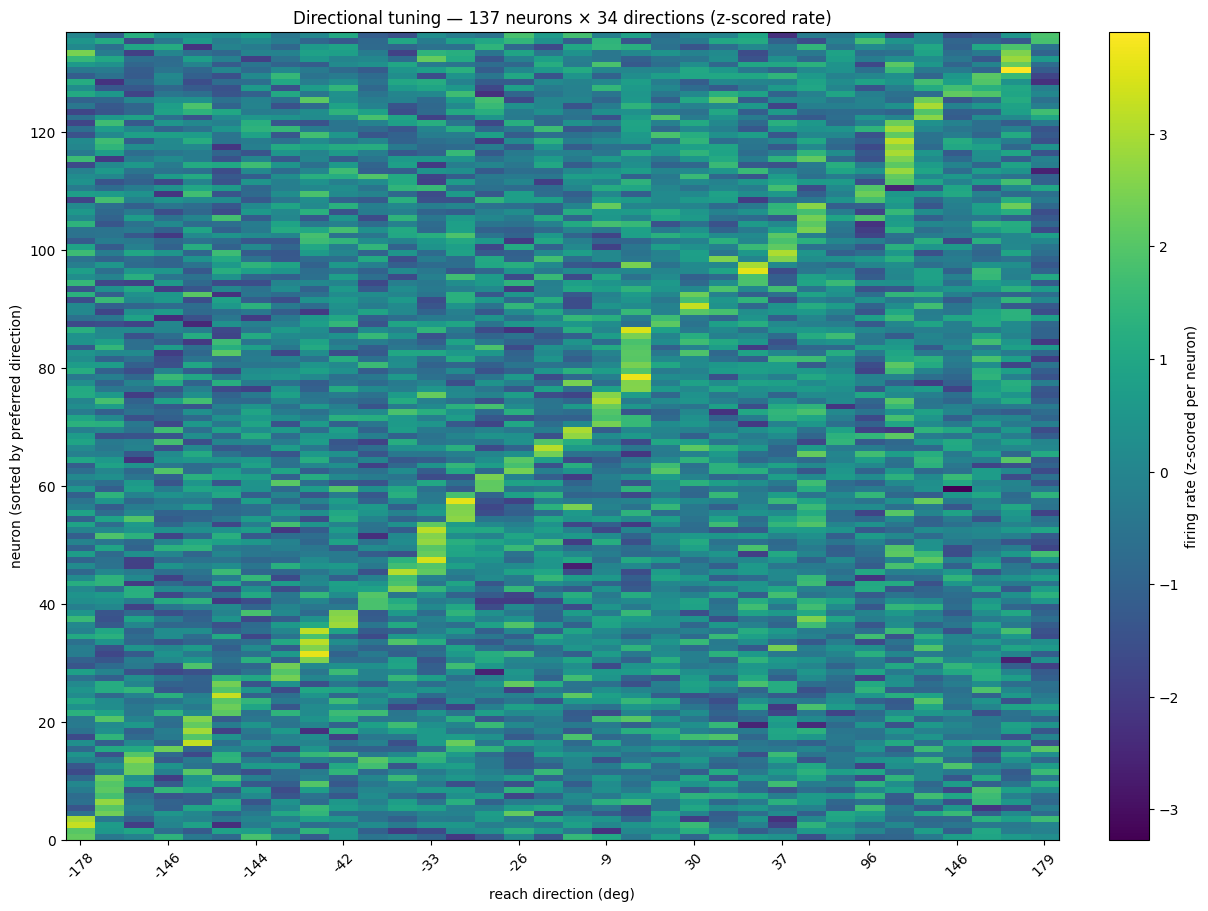

In [9]:
# --- 6. Population directional tuning: 137 neurons x 34 directions ---
#     >>> Run this AFTER writing your prediction in the top cell. <<<
def plot_population_tuning(tuning):
    """Heatmap of directional tuning for every neuron. Each neuron's rates are
    z-scored across directions (so the tuning *shape* shows regardless of baseline
    rate), and neurons are sorted by preferred direction so any population
    structure is visible as a band.
    """
    dirs = np.sort(tuning.index.to_numpy())
    R = tuning.loc[dirs].to_numpy()                 # (directions x neurons), Hz
    Z = (R - R.mean(0)) / (R.std(0) + 1e-9)         # z-score each neuron
    pref = dirs[Z.argmax(0)]                        # preferred direction per neuron
    Zt = Z[:, np.argsort(pref)].T                   # (neurons x directions), sorted

    fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
    im = ax.imshow(Zt, aspect="auto", cmap="viridis", origin="lower",
                   extent=[0, len(dirs), 0, Zt.shape[0]])
    xt = np.arange(0, len(dirs), 3)
    ax.set_xticks(xt + 0.5)
    ax.set_xticklabels([f"{dirs[i]:.0f}" for i in xt], rotation=45)
    ax.set(xlabel="reach direction (deg)",
           ylabel="neuron (sorted by preferred direction)",
           title="Directional tuning \u2014 137 neurons \u00d7 34 directions (z-scored rate)")
    fig.colorbar(im, ax=ax, label="firing rate (z-scored per neuron)")
    return fig


plot_population_tuning(tuning)
plt.show()

## 6b. Split-half heatmap: does preferred direction reproduce?

**Prediction (Prateek, before seeing the real split; paraphrased):** Since neurons
have preferred directions, the diagonal in B should be as strong as in A.

**A and B are different trials of the same neurons, not two neuron groups.**
No cosine is fitted here: a tuning curve is the vector of mean rates across
the 34 sampled target directions.

1. Use complete 500 ms windows, from -100 to +400 ms around movement onset.
2. Randomly split whole trials within each target direction, using seed 42.
   Odd-sized groups give B one extra trial. Each trial belongs to exactly one half.
3. Average A trials by direction. Sort neurons by their largest A response.
4. Compute fresh B averages, but keep exactly the neuron order learned from A.
5. Shuffle direction labels among B trials for one visual control. Entire
   population responses stay together; direction counts stay unchanged.

All panels use each neuron's mean and standard deviation across directions in
A, plus the same fixed color limits. B never sets the row order or scaling.
Negative colors mean below the A mean, not negative firing rates. Columns are
equally spaced sampled directions; the actual angular intervals are uneven.

**What this tests:** reproducibility of direction-grouped rate patterns in this
session. A surviving B pattern is not proof of a cosine law, a causal role for
target direction, or stability across sessions. Target angle remains entangled
with maze configuration and movement. One shuffled panel is not a significance test.

**Timing correction, 2026-09-13:** this experiment exposed nonchronological native
timestamps upstream of the old positional binning. Section 2 now sorts and
validates the native clock before binning. Earlier saved tuning/PCA outputs are
historical and must be rerun before interpretation. The raw-NWB check below
validates the corrected rates independently.

Run setup sections 1-3 before the code below. The synthetic checks do not use
the real result to choose the split or thresholds.

In [6]:
import numpy as np
import pandas as pd


def split_half_tuning(rates, directions, seed=42):
    """Split whole trials within direction; learn neuron order and scaling from A only."""
    if not rates.index.is_unique or not directions.index.is_unique:
        raise ValueError("Trial IDs must be unique.")
    directions = directions.reindex(rates.index)
    if rates.empty or not np.isfinite(rates.to_numpy()).all():
        raise ValueError("Rates must be nonempty and finite.")
    if not np.isfinite(directions.to_numpy()).all() or directions.nunique() < 2:
        raise ValueError("Every trial needs a finite direction; at least two directions are required.")

    rng = np.random.default_rng(seed)
    assignment = pd.Series("", index=rates.index, name="half")
    for angle, trial_ids in directions.groupby(directions, sort=True).groups.items():
        if len(trial_ids) < 2:
            raise ValueError(f"Direction {angle} needs at least two trials.")
        shuffled_ids = rng.permutation(trial_ids)
        midpoint = len(shuffled_ids) // 2
        assignment.loc[shuffled_ids[:midpoint]] = "A"
        assignment.loc[shuffled_ids[midpoint:]] = "B"

    ids_a = assignment.index[assignment.eq("A")]
    ids_b = assignment.index[assignment.eq("B")]
    directions_a = directions.loc[ids_a]
    directions_b = directions.loc[ids_b]
    shuffled_directions_b = pd.Series(
        rng.permutation(directions_b.to_numpy()), index=ids_b, name=directions.name,
    )
    means = {
        "A": rates.loc[ids_a].groupby(directions_a).mean().sort_index(),
        "B": rates.loc[ids_b].groupby(directions_b).mean().sort_index(),
        "B shuffled": rates.loc[ids_b].groupby(shuffled_directions_b).mean().sort_index(),
    }
    center_a = means["A"].mean(axis=0)
    scale_a = means["A"].std(axis=0, ddof=0)
    retained = scale_a > 1e-12
    if not retained.any():
        raise ValueError("No neuron varies across directions in half A.")
    excluded_neurons = rates.columns[~retained].tolist()
    means = {name: mean.loc[:, retained] for name, mean in means.items()}
    scaled = {
        name: (mean - center_a[retained]) / scale_a[retained]
        for name, mean in means.items()
    }
    peaks_a = means["A"].to_numpy().argmax(axis=0)
    neuron_order = np.argsort(peaks_a, kind="stable")
    counts = pd.crosstab(directions, assignment).reindex(means["A"].index)
    assert len(ids_a.intersection(ids_b)) == 0
    assert counts.sum().sum() == len(rates)
    assert (counts["A"] - counts["B"]).abs().le(1).all()
    assert shuffled_directions_b.value_counts().sort_index().equals(
        directions_b.value_counts().sort_index()
    )
    return {
        "means": means, "scaled": scaled, "peaks_a": peaks_a,
        "neuron_order": neuron_order, "assignment": assignment,
        "counts": counts, "excluded_neurons": excluded_neurons, "seed": seed,
    }


def check_split_half_tuning():
    """Check known signal, pure noise, reproducibility, and independence from B."""
    signal_directions = pd.Series(np.repeat([-135.0, -45.0, 45.0, 135.0], 11))
    signal_rates = pd.DataFrame(np.repeat(10 + 20 * np.eye(4), 11, axis=0))
    signal_rates["constant"] = 5.0
    signal = split_half_tuning(signal_rates, signal_directions)
    pd.testing.assert_frame_equal(signal["scaled"]["A"], signal["scaled"]["B"])
    assert signal["excluded_neurons"] == ["constant"]
    repeated = split_half_tuning(signal_rates, signal_directions)
    pd.testing.assert_series_equal(signal["assignment"], repeated["assignment"])
    changed_rates = signal_rates.copy()
    changed_rates.loc[signal["assignment"].eq("B")] += 100
    changed = split_half_tuning(changed_rates, signal_directions)
    pd.testing.assert_frame_equal(signal["scaled"]["A"], changed["scaled"]["A"])
    np.testing.assert_array_equal(signal["neuron_order"], changed["neuron_order"])

    noise_rng = np.random.default_rng(7)
    noise_directions = pd.Series(np.repeat(np.arange(34), 40))
    noise_rates = pd.DataFrame(noise_rng.poisson(15, size=(len(noise_directions), 64)))
    noise = split_half_tuning(noise_rates, noise_directions)
    neuron_indices = np.arange(noise["scaled"]["A"].shape[1])
    ridge_a = noise["scaled"]["A"].to_numpy()[noise["peaks_a"], neuron_indices].mean()
    ridge_b = noise["scaled"]["B"].to_numpy()[noise["peaks_a"], neuron_indices].mean()
    assert ridge_a > 1.0 and abs(ridge_b) < 0.5
    print("Split-half checks passed: disjoint/balanced trials, fixed A order, signal/noise controls.")


check_split_half_tuning()

Split-half checks passed: disjoint/balanced trials, fixed A order, signal/noise controls.


Loaded trials: 2295
Absent from aligned data: 0
Incomplete windows excluded: 0
Complete trials used: 2295; bins per trial: 25
Trials per half: {'A': 1140, 'B': 1155}
Trials per direction and half: min 27 ; max 66
Neurons excluded for constant A tuning: []
Median per-neuron A/B tuning correlation: 0.830
Mean A-selected peak contrast above each half's direction mean (A SDs):
  A: 2.504
  B: 1.797
  B shuffled: -0.000


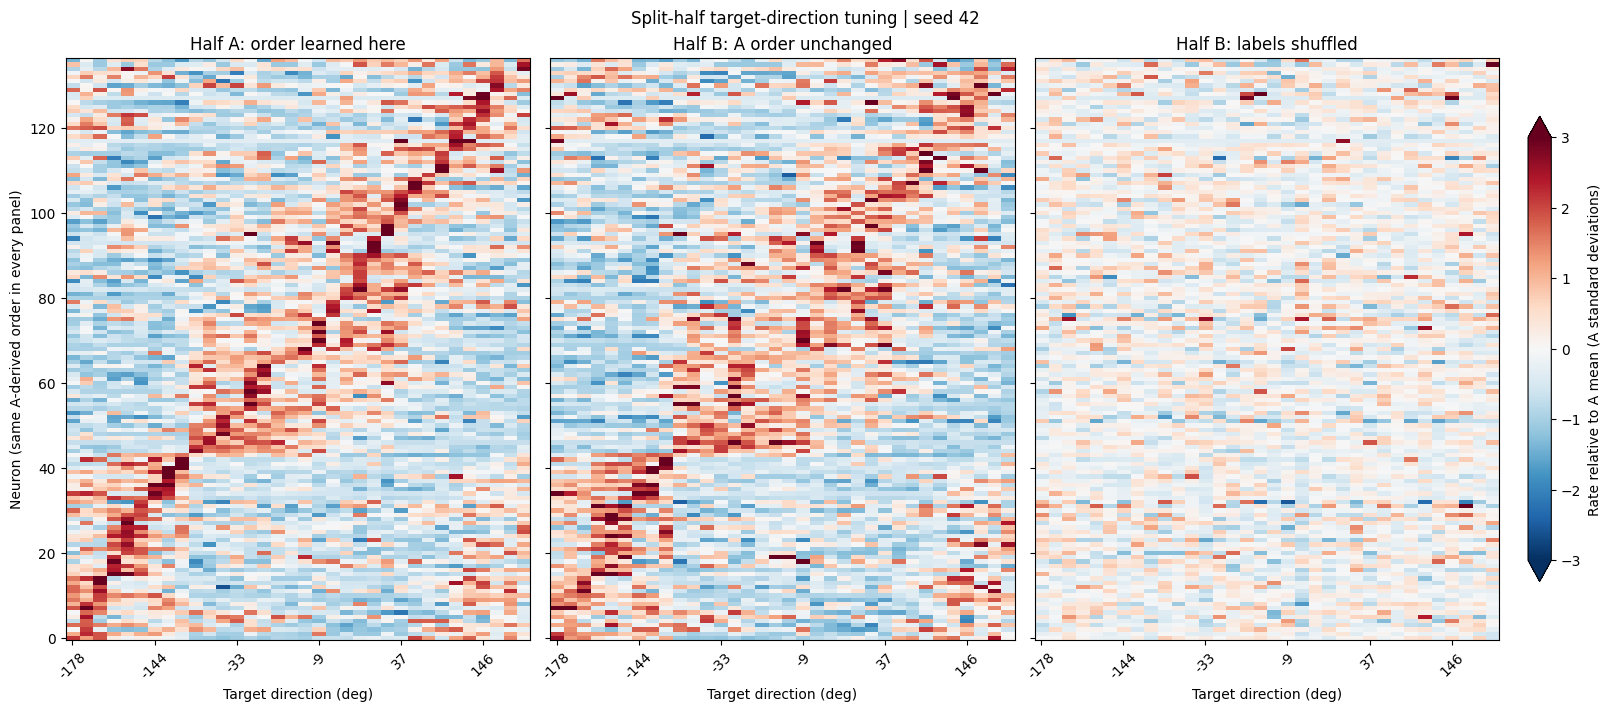

In [12]:
import matplotlib.pyplot as plt


def plot_split_half_tuning(result):
    """Display independent trial halves and a label-shuffle control in A's fixed order."""
    angles = result["means"]["A"].index.to_numpy()
    order = result["neuron_order"]
    panel_titles = [
        "Half A: order learned here",
        "Half B: A order unchanged",
        "Half B: labels shuffled",
    ]
    figure, axes = plt.subplots(
        1, 3, figsize=(16, 7), sharex=True, sharey=True, constrained_layout=True,
    )
    ticks = np.arange(0, len(angles), 6)
    for axis, name, title in zip(axes, ["A", "B", "B shuffled"], panel_titles):
        image = axis.imshow(
            result["scaled"][name].to_numpy()[:, order].T,
            aspect="auto", origin="lower", interpolation="nearest",
            cmap="RdBu_r", vmin=-3, vmax=3,
        )
        axis.set_xticks(ticks)
        axis.set_xticklabels([f"{angles[tick]:.0f}" for tick in ticks], rotation=45)
        axis.set(title=title, xlabel="Target direction (deg)")
    axes[0].set_ylabel("Neuron (same A-derived order in every panel)")
    figure.colorbar(
        image, ax=list(axes), shrink=0.8, pad=0.02, extend="both",
        label="Rate relative to A mean (A standard deviations)",
    )
    figure.suptitle(f"Split-half target-direction tuning | seed {result['seed']}")
    return figure


split_window_ms = (-100, 400)
split_trial_data = dataset.make_trial_data(
    align_field="move_onset_time", align_range=split_window_ms,
 )
split_spikes = split_trial_data["spikes"].copy()
split_spikes["trial_id"] = split_trial_data["trial_id"].to_numpy().ravel()
split_bin_counts = split_spikes.groupby("trial_id").count()
expected_split_bins = int((split_window_ms[1] - split_window_ms[0]) / dataset.bin_width)
complete_split_ids = split_bin_counts.index[split_bin_counts.eq(expected_split_bins).all(axis=1)]
split_rates = split_spikes.groupby("trial_id").sum().loc[complete_split_ids] / 0.5
split_directions = reach_conditions(dataset).set_index("trial_id")["reach_angle_deg"].round(1)
split_half_result = split_half_tuning(split_rates, split_directions, seed=42)

print(f"Loaded trials: {len(dataset.trial_info)}")
print(f"Absent from aligned data: {len(dataset.trial_info) - len(split_bin_counts)}")
print(f"Incomplete windows excluded: {len(split_bin_counts) - len(complete_split_ids)}")
print(f"Complete trials used: {len(split_rates)}; bins per trial: {expected_split_bins}")
print("Trials per half:", split_half_result["counts"].sum().to_dict())
print("Trials per direction and half: min", int(split_half_result["counts"].min().min()),
      "; max", int(split_half_result["counts"].max().max()))
print("Neurons excluded for constant A tuning:", split_half_result["excluded_neurons"])

split_half_correlations = split_half_result["means"]["A"].corrwith(split_half_result["means"]["B"])
print(f"Median per-neuron A/B tuning correlation: {split_half_correlations.median():.3f}")
print("Mean A-selected peak contrast above each half's direction mean (A SDs):")
split_neuron_indices = np.arange(len(split_half_result["peaks_a"]))
for panel_name, panel_rates in split_half_result["scaled"].items():
    panel_values = panel_rates.to_numpy()
    peak_contrast = panel_values[split_half_result["peaks_a"], split_neuron_indices] - panel_values.mean(axis=0)
    print(f"  {panel_name}: {peak_contrast.mean():.3f}")

split_half_figure = plot_split_half_tuning(split_half_result)
split_half_figure.savefig(
    TRAIN_NWB.parents[3] / "assets" / "mcmaze_split_half_tuning.png", dpi=150, bbox_inches="tight",
 )
plt.show()

In [13]:
from pynwb import NWBHDF5IO


audit_trial_ids = complete_split_ids[np.linspace(0, len(complete_split_ids) - 1, 5, dtype=int)]
audit_unit_ids = split_rates.columns[np.linspace(0, len(split_rates.columns) - 1, 5, dtype=int)]
audit_counts = []
with NWBHDF5IO(str(TRAIN_NWB), "r") as audit_io:
    audit_nwb = audit_io.read()
    audit_unit_rows = {unit_id: row for row, unit_id in enumerate(audit_nwb.units.id[:])}
    for audit_trial_id in audit_trial_ids:
        audit_rows = split_trial_data.loc[
            split_trial_data["trial_id"].to_numpy().ravel() == audit_trial_id
        ]
        audit_clock = pd.to_timedelta(audit_rows["clock_time"].to_numpy().ravel())
        audit_start_ms = int(round(audit_clock[0].total_seconds() * 1000))
        audit_end_ms = int(round(audit_clock[-1].total_seconds() * 1000 + dataset.bin_width))
        audit_time_mask = (dataset.data.index >= audit_clock[0]) & (
            dataset.data.index < audit_clock[-1] + pd.Timedelta(milliseconds=dataset.bin_width)
        )
        for audit_unit_id in audit_unit_ids:
            audit_times = np.asarray(audit_nwb.units["spike_times"][audit_unit_rows[audit_unit_id]])
            audit_spike_ms = np.round(audit_times * 1000, 6).astype(np.int64)
            raw_count = np.count_nonzero(
                (audit_spike_ms >= audit_start_ms) & (audit_spike_ms < audit_end_ms)
            )
            continuous_count = dataset.data.loc[audit_time_mask, ("spikes", audit_unit_id)].sum()
            binned_count = split_rates.loc[audit_trial_id, audit_unit_id] * 0.5
            audit_counts.append((audit_trial_id, audit_unit_id, raw_count, continuous_count, binned_count))

split_count_audit = pd.DataFrame(
    audit_counts, columns=["trial_id", "unit_id", "raw_count", "continuous_count", "binned_count"],
 )
print(split_count_audit.to_string(index=False))
np.testing.assert_allclose(split_count_audit["raw_count"], split_count_audit["binned_count"], atol=1e-6, rtol=0)
print(f"Raw-NWB count check passed for {len(split_count_audit)} trial/neuron pairs.")

 trial_id  unit_id  raw_count  continuous_count  binned_count
        0     1011          1               1.0           1.0
        0     1372          0               0.0           0.0
        0     2051          0               0.0           0.0
        0     2541          0               0.0           0.0
        0     2961         24              24.0          24.0
      573     1011          0               0.0           0.0
      573     1372          2               2.0           2.0
      573     2051          0               0.0           0.0
      573     2541          0               0.0           0.0
      573     2961         16              16.0          16.0
     1147     1011          0               0.0           0.0
     1147     1372          2               2.0           2.0
     1147     2051          0               0.0           0.0
     1147     2541          0               0.0           0.0
     1147     2961         15              15.0          15.0
     172

/Users/prateekkarkare/Desktop/Personal/Projects/motor-cortex-population-dynamics/.venv/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.4.0, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


### Split-half result and the timing bug (2026-09-13)

**The diagonal survives in B, but is weaker than in A.** The corrected run uses
all 2,295 trials: 1,140 in A and 1,155 in B, with 27-66 trials per direction per
half. All 137 neurons are retained. The median per-neuron Pearson correlation
between A and B tuning curves is **0.830**.

| Panel | Mean A-selected peak contrast (A standard deviations) |
|---|---:|
| A, selected and displayed on A | 2.504 |
| Independent B, A order unchanged | 1.797 |
| B with shuffled trial labels, A order unchanged | approximately 0.000 |

Peak contrast subtracts each panel's own across-direction mean for each neuron
before averaging over neurons, so an overall firing-rate offset is not counted
as a ridge. It is descriptive, not a fraction of neurons tuned or a p-value.

**Why B can be weaker despite real tuning:** A's selected maximum benefits from
both signal and favorable noise. B shares the reproducible signal, but its noise
does not have to favor that same direction. Here B retains about 72% of A's peak
contrast. Prateek's prediction was supported on survival, but not equal strength.

**Do not interpret the first attempted heatmap.** With the old binning it showed
median correlation 0.017, but raw spike counts disagreed for 9 of 25 sampled
trial/neuron pairs. The loader's native time index was not chronological.
Summing consecutive rows before sorting, then replacing the clock with a
regular index, assigned spike counts to incorrect times. Sorting the native
timestamps before binning fixes the sampled count discrepancies and also
restores the 47 trials previously dropped as missing.

Validation: synthetic known-signal/noise controls, disjoint balanced trial IDs,
fixed A-only ordering, and direct agreement with raw spike timestamps for five
trials spanning the session and five neurons (25 pairs). A separate shuffled-row
binning regression also passed. This spot check is not a full-data audit.

The old cosine-fit and PCA numbers in the historical plots/log have **not** been
recomputed. Neither the old weak fits nor the old 17-21-PC counts should guide
the neuroscience interpretation until those analyses are rerun.

The 2010 paper's PCA uses conditions x (neurons x time), not this static
direction x neuron matrix; its Figure 8 oscillator is simulated. The present
result establishes reproducibility of direction-associated responses in this
analysis, not a specific encoding mechanism or population dynamics.

![Corrected split-half heatmaps](../assets/mcmaze_split_half_tuning.png)

## 6c. Distribution across 20 random trial splits

**Question:** was the high A/B correlation specific to the trial partition chosen
by seed 42? Reuse the corrected rates from section 6b and repeat the same split
procedure for seeds 42 through 61, including the original split.

Within each split, calculate Pearson correlation across the 34 direction means
for each neuron, then take the median across neurons. Repeat the calculation
after shuffling B's trial labels, keeping population responses together and
preserving the number of trials at each direction. Each split has its own control.

Keep A and B estimates separate within each split. Do not average A curves across
splits and then compare them with averaged B curves: those estimates would reuse
the same trials on both sides. More splits measure sensitivity to partitioning;
they do not provide more independently recorded trials.

**Reading the plot:** each dot is one split's median across neurons, not one
neuron. Horizontal position is the correlation; the small vertical spread merely
separates overlapping dots. A black tick marks the median of the 20 split medians,
and a horizontal segment spans their minimum and maximum. No histogram bins or
density smoothing are needed to display these 20 values.

Pearson correlation is undefined for a constant curve. Verify such cases and
exclude that neuron from both real and shuffled medians for that split; never
replace an undefined value with zero. The table reports every exclusion.

The range is descriptive partition sensitivity, **not a confidence interval**.
The splits reuse trials; the 20 medians are not 20 independent experiments, and
the shuffled panels are illustrative controls rather than a calibrated p-value.

Run section 6b first. The checks require seed 42 to reproduce its original
assignment and per-neuron correlations, and all 20 partitions to be distinct.

Checks passed: 20 distinct balanced/disjoint partitions; seed 42 reproduced exactly.
Undefined correlations were verified to come only from constant curves, never replaced by zero.
Within each split, real and shuffled medians use the same paired finite neurons.
      A vs B  A vs shuffled B  paired neurons  undefined A/B  undefined shuffle  excluded constant A  A trials  B trials
seed                                                                                                                    
42    0.8304          -0.0102             137              0                  0                    0      1140      1155
43    0.8269           0.0839             137              0                  0                    0      1140      1155
44    0.8356           0.0026             137              0                  0                    0      1140      1155
45    0.8247          -0.0165             137              0                  0                    0      1140      1155
46    0.8256

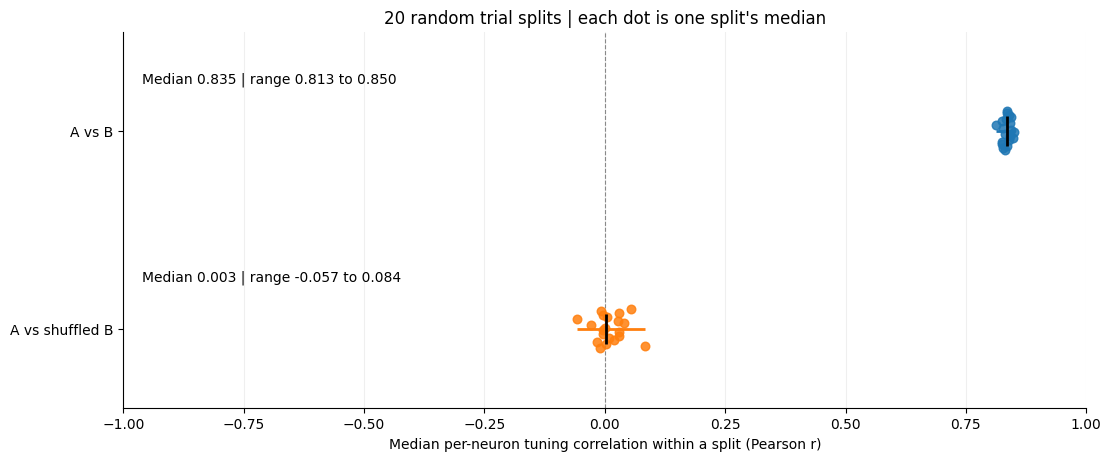

In [15]:
repeated_split_seeds = list(range(42, 62))
repeated_split_rows = []
repeated_neuron_correlations = []
repeated_partition_keys = set()

for repeated_seed in repeated_split_seeds:
    repeated_result = split_half_tuning(split_rates, split_directions, seed=repeated_seed)
    repeated_means = repeated_result["means"]
    repeated_correlations = pd.DataFrame({
        "A vs B": repeated_means["A"].corrwith(repeated_means["B"]),
        "A vs shuffled B": repeated_means["A"].corrwith(repeated_means["B shuffled"]),
    })
    repeated_flat_curves = {
        name: means.nunique().eq(1) for name, means in repeated_means.items()
    }
    repeated_expected_missing = pd.DataFrame({
        "A vs B": repeated_flat_curves["A"] | repeated_flat_curves["B"],
        "A vs shuffled B": repeated_flat_curves["A"] | repeated_flat_curves["B shuffled"],
    })
    pd.testing.assert_frame_equal(repeated_correlations.isna(), repeated_expected_missing)
    repeated_valid = repeated_correlations.notna().all(axis=1)
    assert repeated_valid.any(), "No paired finite correlations in this split."
    assert np.isfinite(repeated_correlations.loc[repeated_valid].to_numpy()).all()
    assert (repeated_correlations.loc[repeated_valid].abs() <= 1 + 1e-12).all().all()
    repeated_partition_keys.add(tuple(
        repeated_result["assignment"].index[repeated_result["assignment"].eq("A")]
    ))
    if repeated_seed == split_half_result["seed"]:
        pd.testing.assert_series_equal(repeated_result["assignment"], split_half_result["assignment"])
        pd.testing.assert_series_equal(
            repeated_correlations["A vs B"], split_half_correlations, check_names=False,
        )
    repeated_split_rows.append({
        "seed": repeated_seed,
        "A vs B": repeated_correlations.loc[repeated_valid, "A vs B"].median(),
        "A vs shuffled B": repeated_correlations.loc[repeated_valid, "A vs shuffled B"].median(),
        "paired neurons": int(repeated_valid.sum()),
        "undefined A/B": int(repeated_correlations["A vs B"].isna().sum()),
        "undefined shuffle": int(repeated_correlations["A vs shuffled B"].isna().sum()),
        "excluded constant A": len(repeated_result["excluded_neurons"]),
        "A trials": int(repeated_result["counts"]["A"].sum()),
        "B trials": int(repeated_result["counts"]["B"].sum()),
    })
    repeated_correlations["used in paired median"] = repeated_valid
    repeated_neuron_correlations.append(repeated_correlations)

repeated_split_results = pd.DataFrame(repeated_split_rows).set_index("seed")
repeated_per_neuron = pd.concat(
    repeated_neuron_correlations, keys=repeated_split_seeds, names=["seed", "neuron"],
 )
assert len(repeated_partition_keys) == len(repeated_split_seeds)
assert repeated_split_results[["A trials", "B trials"]].nunique().eq(1).all()
repeated_split_summary = repeated_split_results[["A vs B", "A vs shuffled B"]].agg(
    ["median", "min", "max"],
 ).T
print("Checks passed: 20 distinct balanced/disjoint partitions; seed 42 reproduced exactly.")
print("Undefined correlations were verified to come only from constant curves, never replaced by zero.")
print("Within each split, real and shuffled medians use the same paired finite neurons.")
print(repeated_split_results.to_string(float_format=lambda value: f"{value:.4f}"))
print("\nDescriptive spread across trial partitions (not a confidence interval):")
print(repeated_split_summary.to_string(float_format=lambda value: f"{value:.4f}"))
if not repeated_per_neuron["used in paired median"].all():
    print("\nExcluded neuron/split pairs (undefined Pearson correlation):")
    print(repeated_per_neuron.loc[~repeated_per_neuron["used in paired median"]].to_string())

repeated_split_figure, repeated_axis = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
repeated_plot_groups = [("A vs B", 1, "tab:blue"), ("A vs shuffled B", 0, "tab:orange")]
repeated_dot_offsets = np.linspace(-0.10, 0.10, len(repeated_split_seeds))
for repeated_label, repeated_position, repeated_color in repeated_plot_groups:
    repeated_values = repeated_split_results[repeated_label].to_numpy()
    repeated_axis.hlines(
        repeated_position, repeated_values.min(), repeated_values.max(),
        color=repeated_color, linewidth=2, zorder=1,
    )
    repeated_axis.scatter(
        repeated_values, repeated_position + repeated_dot_offsets,
        color=repeated_color, s=38, alpha=0.85, zorder=2,
    )
    repeated_axis.plot(
        np.median(repeated_values), repeated_position, marker="|",
        color="black", markersize=22, markeredgewidth=2, zorder=3,
    )
    repeated_axis.text(
        -0.96, repeated_position + 0.26,
        f"Median {np.median(repeated_values):.3f} | range {repeated_values.min():.3f} to {repeated_values.max():.3f}",
        fontsize=10, va="center",
    )
repeated_axis.axvline(0, color="0.5", linewidth=0.8, linestyle="--", zorder=0)
repeated_axis.set(
    xlim=(-1, 1), ylim=(-0.4, 1.5), yticks=[0, 1],
    yticklabels=["A vs shuffled B", "A vs B"],
    xlabel="Median per-neuron tuning correlation within a split (Pearson r)",
    title="20 random trial splits | each dot is one split's median",
 )
repeated_axis.grid(axis="x", alpha=0.2)
repeated_axis.spines[["top", "right"]].set_visible(False)
repeated_split_figure.savefig(
    TRAIN_NWB.parents[3] / "assets" / "mcmaze_repeated_split_correlations.png",
    dpi=150, bbox_inches="tight",
 )
plt.show()

### Repeated-split result (2026-09-13)

| Within-split statistic | Median across 20 splits | Minimum | Maximum |
|---|---:|---:|---:|
| Median per-neuron A/B correlation | 0.8352 | 0.8126 | 0.8495 |
| Median per-neuron A/shuffled-B correlation | 0.0034 | -0.0572 | 0.0839 |

Every split uses the same 2,295 recorded trials: 1,140 in A and 1,155 in B.
All 20 partitions are distinct and balanced within direction. Seed 42 reproduces
the original assignment and per-neuron A/B correlations exactly.

Neuron 2451 has a constant B curve in seeds 56 and 61. Its real and shuffled
correlations are undefined in those splits, so both medians use the same 136
remaining neurons. The other 18 splits use all 137. Constant-curve checks passed;
undefined coefficients were not treated as zero.

**Interpretation:** the population-median repeatability stays high across all
20 tested partitions, while shuffled controls remain near zero. The original
0.830 result was not unusually dependent on the partition. Repeating the split
did not make the correlation approach one; it showed that the high correlation
is stable across these random partitions.

These are distributions of population medians, not evidence that every neuron
has correlation near 0.835. The 20 trials splits are not independent experiments,
and the minimum/maximum are not confidence bounds. This remains a within-session
test of direction-associated responses, not proof of a cosine law or causal
direction encoding.

`repeated_split_results` retains all split summaries; `repeated_per_neuron`
retains the individual correlations and the paired-inclusion flags.

![Distribution of repeated-split correlations](../assets/mcmaze_repeated_split_correlations.png)

## 7. PCA — does reach direction live in ~2 dimensions?

Take the trial-averaged tuning matrix (**34 directions × 137 neurons**), centre each
neuron, run PCA. Pure cosine tuning predicts a **2‑D ring** (PC1/PC2 ≈ cos/sin).
First pass (centered): **no ring, PC1+PC2 ≈ 32%, 85% at ~17 PCs.** Two checks:

- **(a) centered vs z‑scored** — centering lets loud, high‑rate neurons dominate;
  z‑scoring each neuron (correlation‑PCA) gives every neuron an equal vote and could
  surface a weak *shared* ring.
- **(b) straight reaches only** — the maze confounds *direction* with *path*, so we
  restrict to low‑curvature (near‑straight) reaches to test direction more fairly.

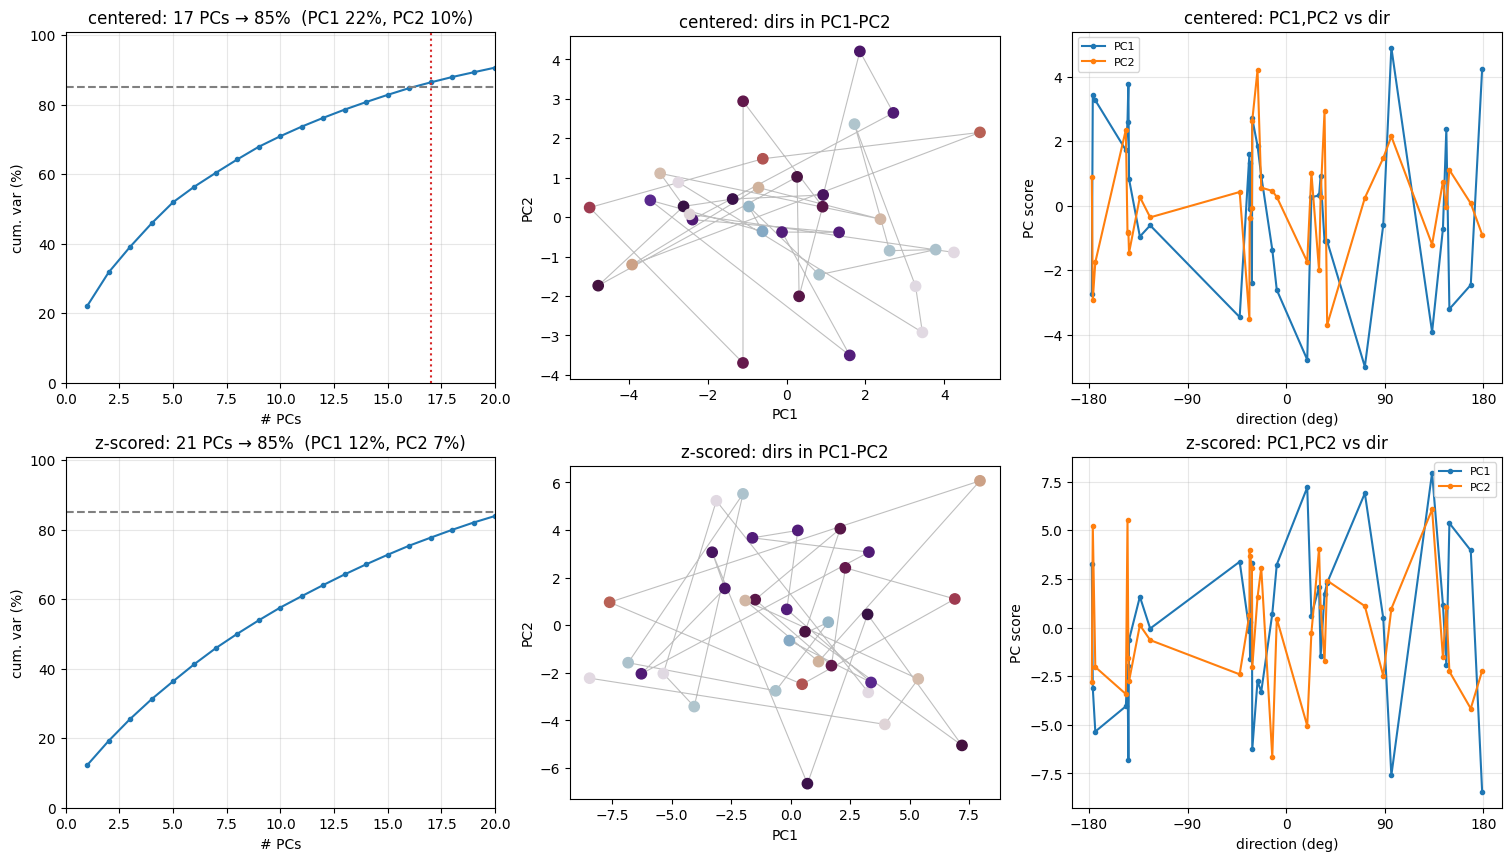

In [6]:
# --- 7. PCA of the trial-averaged tuning matrix (centered vs z-scored) ---
def pca_and_plot(D, axes, standardize=False, tag=""):
    """PCA of a (directions x neurons) tuning matrix; draw 3 panels into `axes`
    (cumulative variance, PC1-PC2 scatter, PC1/PC2 vs direction).

    standardize=True z-scores each neuron first (correlation-PCA) so every neuron
    gets an equal vote instead of loud high-rate neurons dominating.
    """
    dirs = np.sort(D.index.to_numpy())
    X = D.loc[dirs].to_numpy().astype(float)
    Xc = X - X.mean(0, keepdims=True)
    if standardize:
        Xc = Xc / (X.std(0, keepdims=True) + 1e-9)
    U, S, _ = np.linalg.svd(Xc, full_matrices=False)
    var = S ** 2 / np.sum(S ** 2)
    cum = np.cumsum(var)
    scores = U * S
    n85 = int(np.searchsorted(cum, 0.85) + 1)

    axV, axR, axC = axes
    axV.plot(np.arange(1, len(cum) + 1), cum * 100, "o-", ms=3)
    axV.axhline(85, color="gray", ls="--")
    axV.axvline(n85, color="tab:red", ls=":")
    axV.set(xlabel="# PCs", ylabel="cum. var (%)", ylim=(0, 101),
            xlim=(0, min(20, len(cum) + 1)),
            title=f"{tag}: {n85} PCs \u2192 85%  (PC1 {var[0]*100:.0f}%, PC2 {var[1]*100:.0f}%)")
    axV.grid(alpha=0.3)

    order = np.argsort(dirs)
    axR.plot(scores[order, 0], scores[order, 1], color="0.75", lw=0.8, zorder=0)
    axR.scatter(scores[:, 0], scores[:, 1], c=dirs, cmap="twilight", s=55, zorder=2)
    axR.set(xlabel="PC1", ylabel="PC2", aspect="equal", title=f"{tag}: dirs in PC1-PC2")

    axC.plot(dirs, scores[:, 0], "o-", ms=3, label="PC1")
    axC.plot(dirs, scores[:, 1], "o-", ms=3, label="PC2")
    axC.set(xlabel="direction (deg)", ylabel="PC score", xticks=np.arange(-180, 181, 90),
            title=f"{tag}: PC1,PC2 vs dir")
    axC.legend(fontsize=8)
    axC.grid(alpha=0.3)
    return var, n85


fig, axes = plt.subplots(2, 3, figsize=(15, 8.5), constrained_layout=True)
pca_and_plot(tuning, axes[0], standardize=False, tag="centered")
pca_and_plot(tuning, axes[1], standardize=True, tag="z-scored")
plt.show()

### 7b. Straight reaches only — remove the maze-path confound

The 34 "directions" are really 34 maze conditions with curved paths. To test whether
*direction itself* is low-dimensional, restrict to **near-straight** reaches:
**tortuosity** = actual cursor path length ÷ straight-line distance (≈1 = straight,
>1 = curved). Keep the straightest 40%, recompute tuning, and PCA again. If direction
lives in 2‑D, the straight-reach ring should be cleaner and 85% should drop.

NaNs found in `self.data`. Dropping 2.05% of points to remove NaNs from `trial_data`.


tortuosity: median 1.25  |  straight cutoff <= 1.18  |  368 straight trials


NaNs found in `self.data`. Dropping 2.05% of points to remove NaNs from `trial_data`.


straight tuning: (34, 137)  |  trials/dir min 3, median 11


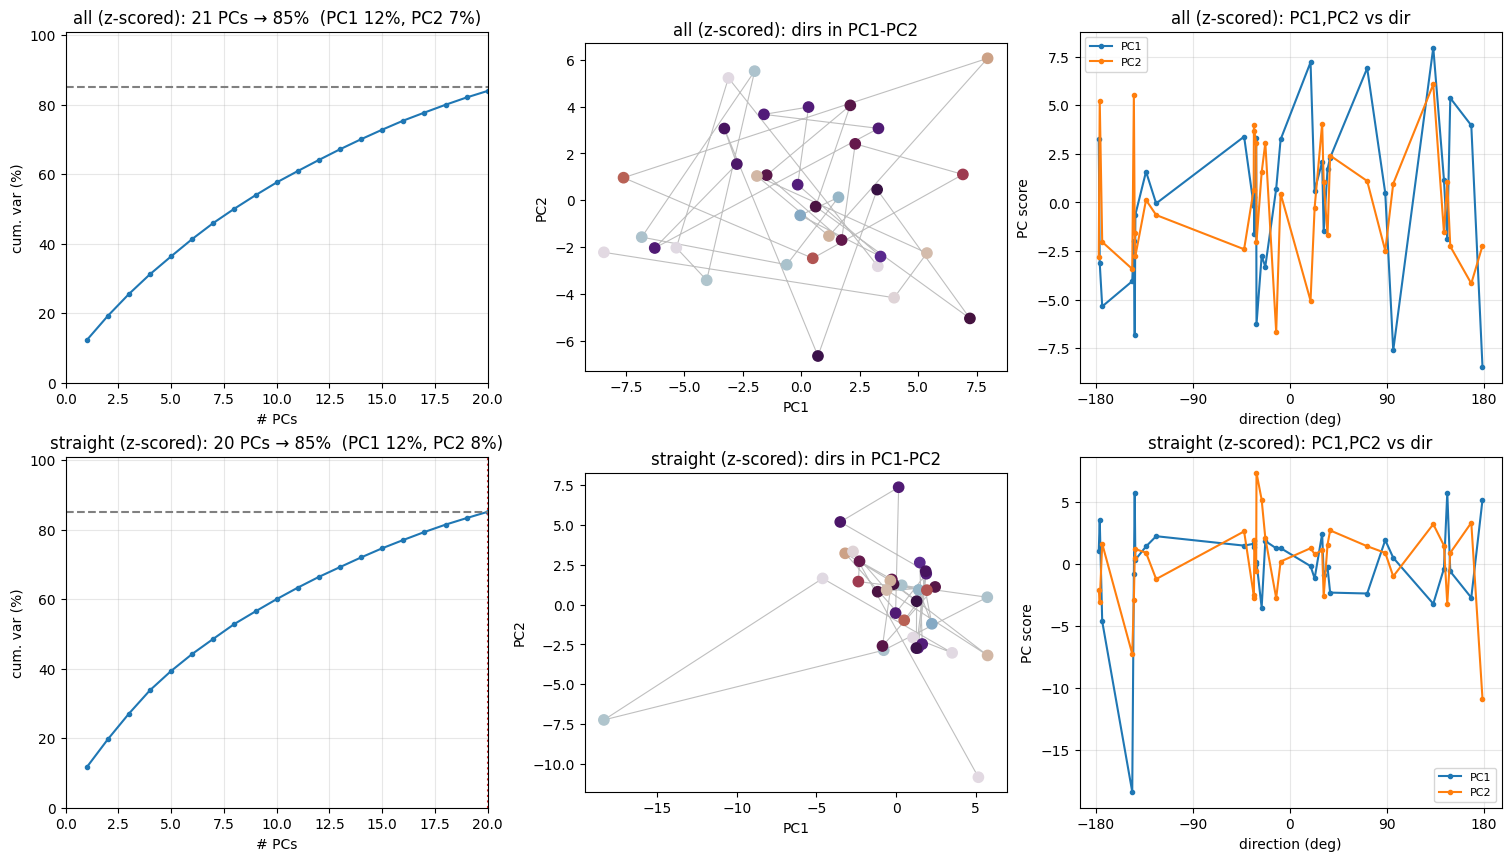

In [7]:
# --- 7b. Straight reaches only (remove the maze-path confound) ---
# tortuosity = cursor path length / straight-line distance over the movement window
_mv = dataset.make_trial_data(align_field="move_onset_time", align_range=(0, 400))
_cur = _mv["cursor_pos"].copy()
_cur["trial_id"] = _mv["trial_id"].to_numpy().ravel()


def _tortuosity(g):
    xy = g[["x", "y"]].dropna().to_numpy()
    if len(xy) < 3:
        return np.nan
    path = np.linalg.norm(np.diff(xy, axis=0), axis=1).sum()
    straight = np.linalg.norm(xy[-1] - xy[0])
    return path / straight if straight > 5 else np.nan


tort = _cur.groupby("trial_id").apply(_tortuosity)
thr = np.nanpercentile(tort, 40)                       # keep straightest 40%
straight_ids = tort[tort <= thr].index
print(f"tortuosity: median {np.nanmedian(tort):.2f}  |  straight cutoff <= {thr:.2f}  |  "
      f"{len(straight_ids)} straight trials")

# recompute tuning on straight trials only
_rates = trial_rates(dataset)
_rc = reach_conditions(dataset).set_index("trial_id")
_keep = _rates.index.intersection(straight_ids)
_sub = _rates.loc[_keep].join(_rc.loc[_keep, "reach_angle_deg"].round(1))
tuning_straight = _sub.groupby("reach_angle_deg").mean()
_nps = _sub.groupby("reach_angle_deg").size()
print(f"straight tuning: {tuning_straight.shape}  |  trials/dir min {_nps.min()}, "
      f"median {int(_nps.median())}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5), constrained_layout=True)
pca_and_plot(tuning, axes[0], standardize=True, tag="all (z-scored)")
pca_and_plot(tuning_straight, axes[1], standardize=True, tag="straight (z-scored)")
plt.show()

## 8. Preparation versus movement: same neurons, different epochs

**Learning question (2026-09-14):** do the conditions favored by a neuron during
preparation remain favored during movement? We will first see neural activity
alongside kinematics, then measure condition-tuning similarity with reliability
controls. This implements the Figure 3/4-style experiments, not a decoder or a
kinematic encoding model.

**Prateek's working prediction, restated:** preparatory and movement condition
preferences may correlate weakly. We must distinguish reliably different
preferences from weakly estimated responses.

**If they look similar:** a strong positive correlation across conditions is
consistent with preparatory activity being a smaller copy of movement activity.
It does not establish that the preparatory amplitude is smaller; inspect raw Hz
and relative modulation as well. It also does not prove causation or rule out
shared inputs or dynamical mechanisms. Two traces merely rising together around
an event are not the same test as preserved condition preferences.

Use the same recorded units and matched trials in both epochs:

| Epoch | Event alignment | Exact rate-averaging window |
|---|---|---|
| Preparatory | Go cue | -200 to +100 ms (300 ms total) |
| Peri-movement | Movement onset | -100 to +350 ms (450 ms total) |

Only successful trials with target-to-go delay >400 ms are included. A condition
is `(maze_id, trial_version)`, retaining 108 target/maze-version combinations
instead of pooling into 34 target directions. Require complete windows inside
the trial and every included unit's observed intervals. The windows do not
overlap in these retained trials.

**Timing:** use raw NWB spike timestamps and exact half-open [start, end) windows.
The 450 ms movement window is not an integer number of our earlier 20 ms bins.
Quantitative rates use no smoothing. Visualization smoothing is separate.

Run the initial imports/path cell (Cell 2) to define `TRAIN_NWB`, then run this
section in order. It reads raw timestamps independently of the historical
binning/tuning/PCA outputs, which have not been recomputed. The first code cell
tests boundary inclusion and verifies 50 trial/unit/epoch counts by direct masks.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO


def event_window_counts(spike_times, window_starts, window_ends):
    """Count spikes in exact half-open [start, end) windows, with times in seconds."""
    spike_times = np.asarray(spike_times, dtype=float)
    window_starts = np.asarray(window_starts, dtype=float)
    window_ends = np.asarray(window_ends, dtype=float)
    if window_starts.shape != window_ends.shape or np.any(window_ends <= window_starts):
        raise ValueError("Window endpoints must have matching shapes and positive durations.")
    if not all(np.isfinite(values).all() for values in [spike_times, window_starts, window_ends]):
        raise ValueError("Spike times and window endpoints must be finite.")
    if np.any(np.diff(spike_times) < 0):
        raise ValueError("Spike timestamps must be chronological.")
    return (np.searchsorted(spike_times, window_ends, side="left")
            - np.searchsorted(spike_times, window_starts, side="left"))


def observed_windows(window_starts, window_ends, observation_intervals):
    """Require the whole window to lie inside a recorded interval."""
    covered = np.zeros(len(window_starts), dtype=bool)
    for interval_start, interval_end in np.asarray(observation_intervals):
        covered |= (window_starts >= interval_start) & (window_ends <= interval_end)
    return covered


np.testing.assert_array_equal(
    event_window_counts([0.0, 0.1, 0.2, 0.3], [0.0, 0.1], [0.2, 0.3]), [2, 2],
 )
np.testing.assert_array_equal(
    observed_windows(np.array([0.0, 0.2]), np.array([0.1, 0.4]), [[0.0, 0.3]]),
    [True, False],
 )

with NWBHDF5IO(str(TRAIN_NWB), "r") as epoch_io:
    epoch_nwb = epoch_io.read()
    epoch_raw_trials = epoch_nwb.trials.to_dataframe().copy()
    epoch_all_units = epoch_nwb.units.to_dataframe()
    epoch_units = epoch_all_units.loc[~epoch_all_units["heldout"].astype(bool)].sort_index().copy()
    epoch_spike_times = {
        unit_id: np.asarray(unit["spike_times"], dtype=float).copy()
        for unit_id, unit in epoch_units.iterrows()
    }

epoch_event_fields = ["start_time", "stop_time", "target_on_time", "go_cue_time", "move_onset_time"]
epoch_long_delay = (epoch_raw_trials["go_cue_time"] - epoch_raw_trials["target_on_time"]) > 0.4
epoch_candidates = epoch_raw_trials.loc[
    epoch_long_delay & epoch_raw_trials["success"].astype(bool)
    & np.isfinite(epoch_raw_trials[epoch_event_fields]).all(axis=1)
].copy()
epoch_window_specs = {
    "preparation": ("go_cue_time", -0.200, 0.100),
    "movement": ("move_onset_time", -0.100, 0.350),
}
epoch_window_bounds = {}
epoch_valid_trials = np.ones(len(epoch_candidates), dtype=bool)
for epoch_name, (event_field, start_offset, end_offset) in epoch_window_specs.items():
    window_starts = epoch_candidates[event_field].to_numpy() + start_offset
    window_ends = epoch_candidates[event_field].to_numpy() + end_offset
    epoch_window_bounds[epoch_name] = (window_starts, window_ends)
    epoch_valid_trials &= (window_starts >= epoch_candidates["start_time"].to_numpy())
    epoch_valid_trials &= (window_ends <= epoch_candidates["stop_time"].to_numpy())
    for observation_intervals in epoch_units["obs_intervals"]:
        epoch_valid_trials &= observed_windows(window_starts, window_ends, observation_intervals)

epoch_trials = epoch_candidates.loc[epoch_valid_trials].copy()
epoch_trials.index.name = "trial_id"
epoch_trials["condition_id"] = pd.factorize(
    pd.MultiIndex.from_frame(epoch_trials[["maze_id", "trial_version"]]), sort=True,
)[0]
epoch_condition_counts = epoch_trials.groupby(["maze_id", "trial_version"]).size()
assert epoch_trials.index.is_unique and epoch_condition_counts.min() >= 4
assert np.all(epoch_window_bounds["preparation"][1][epoch_valid_trials]
              <= epoch_window_bounds["movement"][0][epoch_valid_trials])

epoch_counts = {}
epoch_rates = {}
epoch_count_checks = 0
for epoch_name, (window_starts, window_ends) in epoch_window_bounds.items():
    window_starts = window_starts[epoch_valid_trials]
    window_ends = window_ends[epoch_valid_trials]
    epoch_count_matrix = np.column_stack([
        event_window_counts(spikes, window_starts, window_ends)
        for spikes in epoch_spike_times.values()
    ])
    epoch_counts[epoch_name] = pd.DataFrame(
        epoch_count_matrix, index=epoch_trials.index, columns=epoch_units.index,
    )
    epoch_rates[epoch_name] = epoch_counts[epoch_name].div(window_ends - window_starts, axis=0)
    for trial_position in np.linspace(0, len(epoch_trials) - 1, 5, dtype=int):
        for unit_position in np.linspace(0, len(epoch_units) - 1, 5, dtype=int):
            unit_id = epoch_units.index[unit_position]
            spikes = epoch_spike_times[unit_id]
            mask_count = np.count_nonzero(
                (spikes >= window_starts[trial_position]) & (spikes < window_ends[trial_position])
            )
            assert mask_count == epoch_count_matrix[trial_position, unit_position]
            epoch_count_checks += 1

pd.testing.assert_index_equal(epoch_rates["preparation"].index, epoch_rates["movement"].index)
assert all(np.isfinite(rates.to_numpy()).all() for rates in epoch_rates.values())
epoch_condition_means = {
    name: rates.groupby(epoch_trials["condition_id"]).mean() for name, rates in epoch_rates.items()
}
print(f"Long-delay successful trials: {len(epoch_candidates)}; excluded incomplete/unobserved windows: {int((~epoch_valid_trials).sum())}")
print(f"Matched trials: {len(epoch_trials)}; units: {len(epoch_units)}; conditions: {len(epoch_condition_counts)}")
print(f"Trials per condition: {epoch_condition_counts.min()} to {epoch_condition_counts.max()} (median {epoch_condition_counts.median():.0f})")
print("Preparatory window: go -200 to +100 ms (300 ms); movement window: onset -100 to +350 ms (450 ms).")
print(f"Half-open boundary tests and {epoch_count_checks} direct-mask count checks passed.")

/Users/prateekkarkare/Desktop/Personal/Projects/motor-cortex-population-dynamics/.venv/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.4.0, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Long-delay successful trials: 1967; excluded incomplete/unobserved windows: 0
Matched trials: 1967; units: 137; conditions: 108
Trials per condition: 14 to 24 (median 18)
Preparatory window: go -200 to +100 ms (300 ms); movement window: onset -100 to +350 ms (450 ms).
Half-open boundary tests and 50 direct-mask count checks passed.


### 8a. Visualize neural responses alongside hand kinematics

Split whole trials into A and B within each full condition, using seed 42; the
same split is used for both epochs. For illustrative neurons only, require
condition-mean modulation >5 Hz in A in each epoch, then choose three units with
fixed seed 7. This is an amplitude-based illustration filter, not proof of
tuning. Do not choose neurons by the cross-epoch correlation.

**The plotted responses come from B only.** Choose three mazes spread through
the sampled target-angle ordering and show the no-barrier and barrier versions
of each (six conditions). The statistical comparison below uses all 108
conditions and all 137 units before the explicit reliability screen.

Each color identifies the same condition across every panel. Rows show three
neurons, horizontal hand velocity, vertical hand velocity, and hand speed.
The two columns have separate event alignments; they are not spliced together.
For these long-delay trials, target presentation precedes the left view and
the go cue precedes the right view. Dashed lines mark each view's zero event.

Neural curves: 10 ms bins, Gaussian smoothing with sigma 20 ms, mean +/- SEM
across B trials. Use 80 ms padding to avoid smoothing-edge artifacts. Gray
backgrounds mark the rate-averaging intervals for experiment 2. The wider
plotting windows require complete neural and kinematic coverage in both views;
their exclusion rule does not change the quantitative epoch cohort.

Velocity uses the NWB conversion factor (0.001 to m/s), displayed in cm/s.
Reject gaps, missing samples, and extrapolation when interpolating the raw
kinematics. Speed is computed per trial before averaging, not from the mean
velocity vector. Preparatory velocity being near zero does not imply that
preparatory neural activity is absent or unrelated to the upcoming movement.

**Inspect:** does a color that is high during preparation remain high during
movement? Do the preferences change over the movement itself? Six illustrative
conditions cannot substitute for the full-condition comparison below.

In [17]:
def partition_epoch_trials(condition_ids, seed=42):
    """Use disjoint, balanced trial halves shared by both epochs within each condition."""
    rng = np.random.default_rng(seed)
    assignment = pd.Series("", index=condition_ids.index, name="half")
    for trial_ids in condition_ids.groupby(condition_ids, sort=True).groups.values():
        if len(trial_ids) < 4:
            raise ValueError("Each condition requires at least two trials per half.")
        shuffled_ids = rng.permutation(trial_ids)
        midpoint = len(shuffled_ids) // 2
        assignment.loc[shuffled_ids[:midpoint]] = "A"
        assignment.loc[shuffled_ids[midpoint:]] = "B"
    counts = pd.crosstab(condition_ids, assignment)
    assert counts.min().min() >= 2 and (counts["A"] - counts["B"]).abs().le(1).all()
    assert assignment.isin(["A", "B"]).all()
    return assignment


def condition_curve_correlations(first, second):
    """Pearson correlation across aligned conditions; constant curves remain undefined."""
    pd.testing.assert_index_equal(first.index, second.index)
    pd.testing.assert_index_equal(first.columns, second.columns)
    correlations = first.corrwith(second)
    undefined = first.nunique().eq(1) | second.nunique().eq(1)
    pd.testing.assert_series_equal(correlations.isna(), undefined, check_names=False)
    assert np.isfinite(correlations.dropna()).all()
    return correlations


def compare_epoch_halves(rates, condition_ids, seed=42):
    assignment = partition_epoch_trials(condition_ids, seed)
    means = {}
    for epoch_name, trial_rates_frame in rates.items():
        pd.testing.assert_index_equal(trial_rates_frame.index, condition_ids.index)
        for half in ["A", "B"]:
            half_ids = assignment.index[assignment.eq(half)]
            means[(epoch_name, half)] = trial_rates_frame.loc[half_ids].groupby(condition_ids.loc[half_ids]).mean()
    measures = pd.DataFrame({
        "Preparation A/B": condition_curve_correlations(means[("preparation", "A")], means[("preparation", "B")]),
        "Movement A/B": condition_curve_correlations(means[("movement", "A")], means[("movement", "B")]),
        "Prep A / move B": condition_curve_correlations(means[("preparation", "A")], means[("movement", "B")]),
        "Prep B / move A": condition_curve_correlations(means[("preparation", "B")], means[("movement", "A")]),
    })
    return measures, assignment, means


test_angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
test_conditions = pd.Series(np.repeat(np.arange(16), 8))
test_prep_rates = pd.DataFrame(np.repeat(20 + 5 * np.cos(test_angles), 8), columns=["test_unit"])
test_preserved = {"preparation": test_prep_rates, "movement": 2 * test_prep_rates + 3}
test_measures, _, _ = compare_epoch_halves(test_preserved, test_conditions)
np.testing.assert_allclose(test_measures, 1.0, atol=1e-12)
test_changed = {
    "preparation": test_prep_rates,
    "movement": pd.DataFrame(np.repeat(20 + 5 * np.sin(test_angles), 8), columns=["test_unit"]),
}
test_measures, _, _ = compare_epoch_halves(test_changed, test_conditions)
np.testing.assert_allclose(test_measures[["Preparation A/B", "Movement A/B"]], 1.0, atol=1e-12)
np.testing.assert_allclose(test_measures[["Prep A / move B", "Prep B / move A"]], 0.0, atol=1e-12)
test_flat = pd.DataFrame(np.ones((16, 1)), columns=["test_unit"])
assert condition_curve_correlations(test_flat, test_flat).isna().all()
epoch_first_measures, epoch_assignment, epoch_half_means = compare_epoch_halves(
    epoch_rates, epoch_trials["condition_id"], seed=42,
 )
epoch_example_candidates = epoch_units.index[
    epoch_half_means[("preparation", "A")].apply(np.ptp).gt(5)
    & epoch_half_means[("movement", "A")].apply(np.ptp).gt(5)
]
assert len(epoch_example_candidates) >= 3
epoch_example_units = np.sort(np.random.default_rng(7).choice(epoch_example_candidates, 3, replace=False))
epoch_condition_info = epoch_trials.groupby("condition_id").first()
epoch_condition_info["target_angle_deg"] = [
    np.degrees(np.arctan2(*np.asarray(row["target_pos"])[int(row["active_target"])][::-1]))
    for _, row in epoch_condition_info.iterrows()
]
epoch_maze_order = epoch_condition_info.groupby("maze_id")["target_angle_deg"].first().sort_values().index
epoch_example_mazes = epoch_maze_order[np.linspace(0, len(epoch_maze_order), 3, endpoint=False, dtype=int)]
epoch_example_conditions = epoch_condition_info.index[
    epoch_condition_info["maze_id"].isin(epoch_example_mazes)
    & epoch_condition_info["trial_version"].isin([0, 1])
].tolist()
print("Epoch-comparison controls passed: preserved preferences -> correlation 1; orthogonal preferences -> 0 despite reliability 1.")
print("Selected example neurons using only A modulation >5 Hz in both epochs, then fixed random seed 7:", epoch_example_units.tolist())
print("Plots will use B trials only; examples were not selected by cross-epoch correlation.")
print(epoch_condition_info.loc[epoch_example_conditions, ["maze_id", "trial_version", "target_angle_deg"]].to_string())

Epoch-comparison controls passed: preserved preferences -> correlation 1; orthogonal preferences -> 0 despite reliability 1.
Selected example neurons using only A modulation >5 Hz in both epochs, then fixed random seed 7: [2413, 2472, 2821]
Plots will use B trials only; examples were not selected by cross-epoch correlation.
              maze_id  trial_version  target_angle_deg
condition_id                                          
6                   3              0       -177.531876
7                   3              1       -177.531876
78                 89              0        -32.977722
79                 89              1        -32.977722
90                 95              0         34.957973
91                 95              1         34.957973


/Users/prateekkarkare/Desktop/Personal/Projects/motor-cortex-population-dynamics/.venv/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.4.0, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Displayed B trials per condition: {6: 10, 7: 10, 78: 10, 79: 9, 90: 9, 91: 10}
Neural traces: 10 ms bins, Gaussian sigma 20 ms, shaded mean +/- SEM across B trials.
Gray backgrounds mark the exact unsmoothed rate-averaging windows used by experiment 2.
Kinematics: raw NWB conversion applied, in cm/s; incomplete display windows excluded jointly.


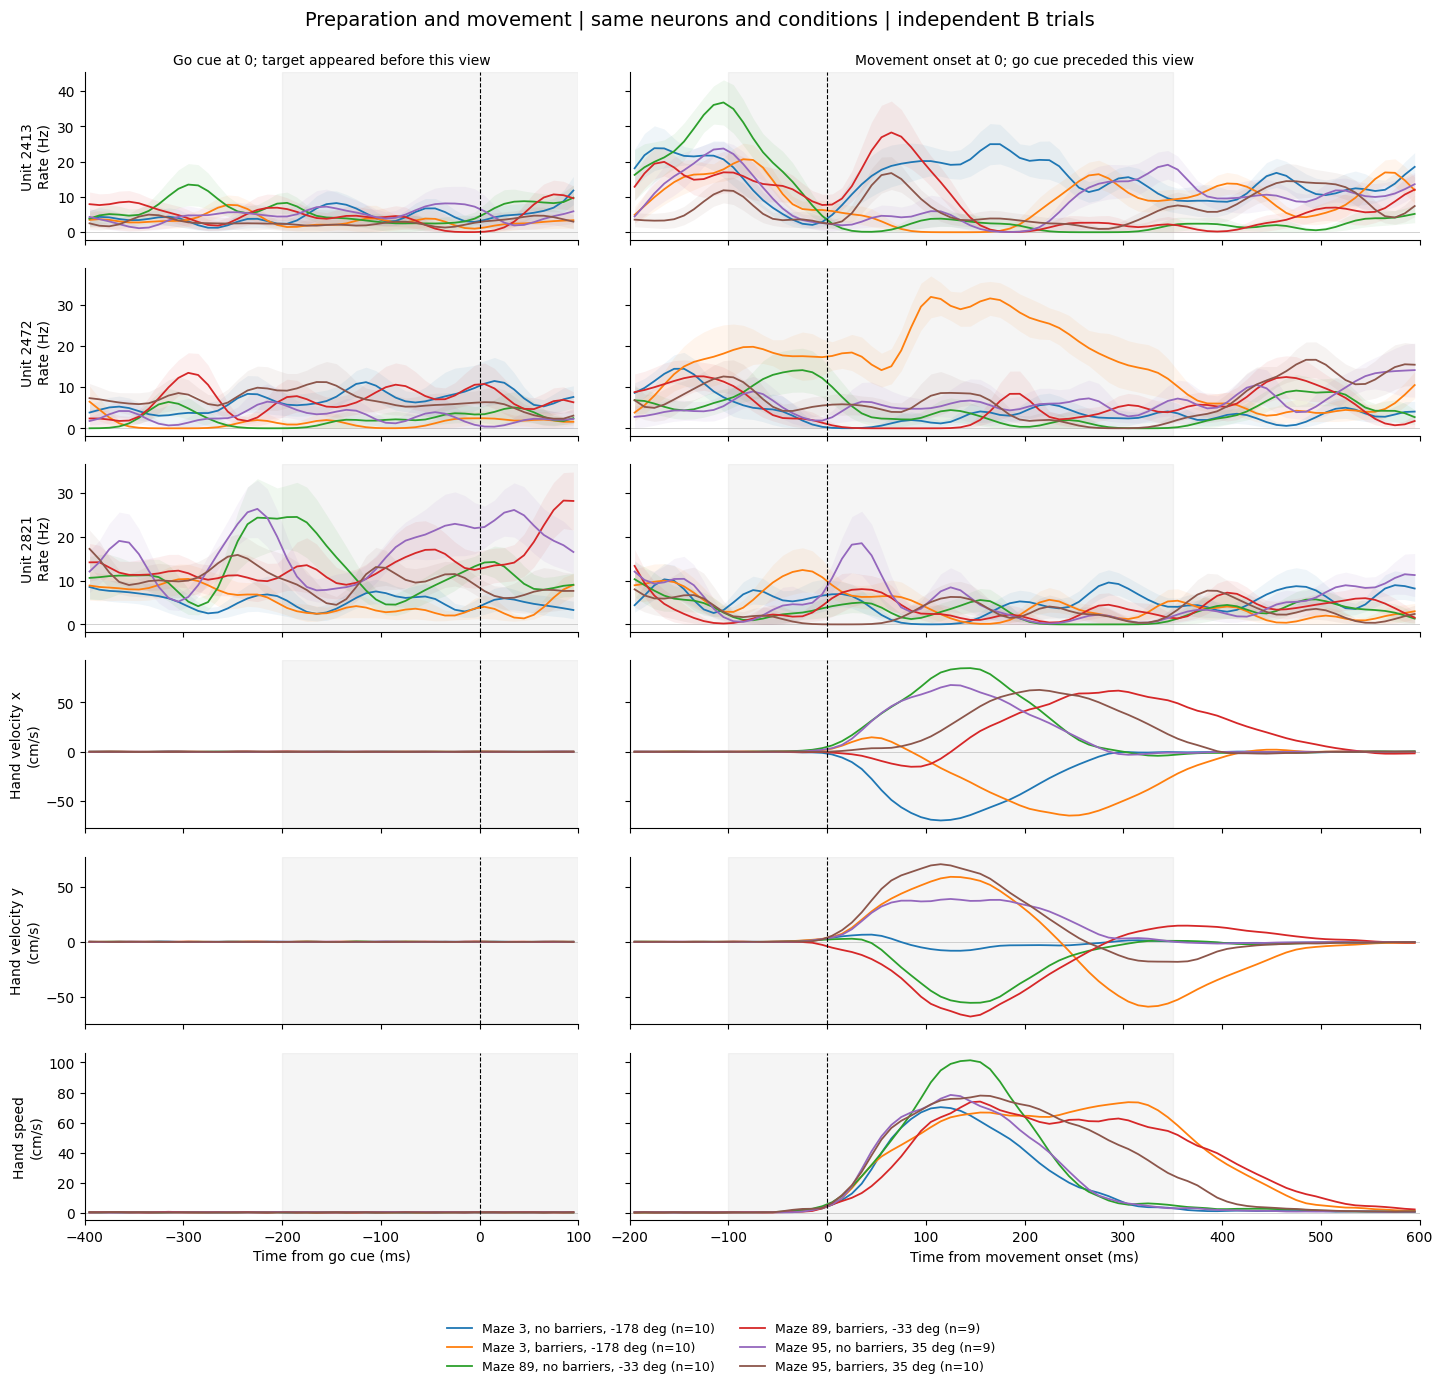

In [18]:
from pynwb import TimeSeries
from scipy.ndimage import gaussian_filter1d


def sample_epoch_timeseries(series, query_times):
    """Interpolate local raw samples, rejecting missing data, gaps, or extrapolation."""
    clock = np.asarray(series.timestamps[:], dtype=float)
    if not np.isfinite(clock).all() or np.any(np.diff(clock) <= 0):
        raise ValueError("Kinematic timestamps must be finite, unique, and chronological.")
    sampled = np.full(query_times.shape + (series.data.shape[1],), np.nan)
    for trial_position, trial_clock in enumerate(query_times):
        left = max(0, np.searchsorted(clock, trial_clock[0], side="right") - 1)
        right = min(len(clock), np.searchsorted(clock, trial_clock[-1], side="left") + 1)
        local_clock = clock[left:right]
        local_values = np.asarray(series.data[left:right], dtype=float)
        if (len(local_clock) < 2 or local_clock[0] > trial_clock[0]
                or local_clock[-1] < trial_clock[-1] or np.any(np.diff(local_clock) > 0.0015)
                or not np.isfinite(local_values).all()):
            continue
        local_values = local_values * series.conversion + series.offset
        for channel in range(local_values.shape[1]):
            sampled[trial_position, :, channel] = np.interp(
                trial_clock, local_clock, local_values[:, channel],
            )
    return sampled


epoch_view_specs = {
    "preparation": ("go_cue_time", -0.400, 0.100),
    "movement": ("move_onset_time", -0.200, 0.600),
}
epoch_plot_bin_s = 0.010
epoch_plot_sigma_s = 0.020
epoch_plot_pad_s = 4 * epoch_plot_sigma_s
epoch_plot_trials = epoch_trials.loc[
    epoch_assignment.eq("B") & epoch_trials["condition_id"].isin(epoch_example_conditions)
].copy()
epoch_plot_covered = np.ones(len(epoch_plot_trials), dtype=bool)
epoch_view_edges = {}
epoch_view_centers = {}
for view_name, (event_field, view_start, view_end) in epoch_view_specs.items():
    sample_count = int(round((view_end - view_start + 2 * epoch_plot_pad_s) / epoch_plot_bin_s))
    edges = view_start - epoch_plot_pad_s + np.arange(sample_count + 1) * epoch_plot_bin_s
    epoch_view_edges[view_name] = edges
    epoch_view_centers[view_name] = (edges[:-1] + edges[1:]) / 2
    support_start = epoch_plot_trials[event_field].to_numpy() + edges[0]
    support_end = epoch_plot_trials[event_field].to_numpy() + edges[-1]
    epoch_plot_covered &= support_start >= epoch_plot_trials["start_time"].to_numpy()
    epoch_plot_covered &= support_end <= epoch_plot_trials["stop_time"].to_numpy()
    for unit_id in epoch_example_units:
        epoch_plot_covered &= observed_windows(support_start, support_end, epoch_units.loc[unit_id, "obs_intervals"])
epoch_plot_trials = epoch_plot_trials.loc[epoch_plot_covered].copy()
assert len(epoch_plot_trials) > 0

epoch_velocity = {}
with NWBHDF5IO(str(TRAIN_NWB), "r") as epoch_kinematics_io:
    epoch_kinematics_nwb = epoch_kinematics_io.read()
    velocity_series = next(
        series for series in epoch_kinematics_nwb.objects.values()
        if isinstance(series, TimeSeries) and series.name == "hand_vel"
    )
    assert velocity_series.unit == "m/s" and "columns=[x,y]" in velocity_series.comments
    for view_name, (event_field, _, _) in epoch_view_specs.items():
        query_times = epoch_plot_trials[event_field].to_numpy()[:, None] + epoch_view_centers[view_name]
        epoch_velocity[view_name] = sample_epoch_timeseries(velocity_series, query_times) * 100

epoch_kinematics_valid = np.ones(len(epoch_plot_trials), dtype=bool)
for sampled_velocity in epoch_velocity.values():
    epoch_kinematics_valid &= np.isfinite(sampled_velocity).all(axis=(1, 2))
epoch_plot_trials = epoch_plot_trials.loc[epoch_kinematics_valid].copy()
epoch_velocity = {name: values[epoch_kinematics_valid] for name, values in epoch_velocity.items()}
epoch_plot_counts = epoch_plot_trials.groupby("condition_id").size().reindex(epoch_example_conditions, fill_value=0)
assert epoch_plot_counts.min() >= 2, "Insufficient fully observed B trials for a selected visual example."

epoch_plot_rates = {}
for view_name, (event_field, _, _) in epoch_view_specs.items():
    absolute_edges = epoch_plot_trials[event_field].to_numpy()[:, None] + epoch_view_edges[view_name]
    counts = np.stack([
        np.diff(np.searchsorted(epoch_spike_times[unit_id], absolute_edges, side="left"), axis=1)
        for unit_id in epoch_example_units
    ], axis=-1)
    assert np.all(counts >= 0)
    epoch_plot_rates[view_name] = gaussian_filter1d(
        counts.astype(float) / epoch_plot_bin_s, epoch_plot_sigma_s / epoch_plot_bin_s,
        axis=1, mode="nearest", truncate=4.0,
    )

epoch_trace_figure, epoch_trace_axes = plt.subplots(
    6, 2, figsize=(15, 14), sharex="col", sharey="row",
    gridspec_kw={"width_ratios": [1, 1.6]},
 )
epoch_colors = {
    condition_id: plt.get_cmap("tab10")(position)
    for position, condition_id in enumerate(epoch_example_conditions)
}
epoch_plot_labels = {}
for condition_id in epoch_example_conditions:
    condition_info = epoch_condition_info.loc[condition_id]
    variant_name = "no barriers" if condition_info["trial_version"] == 0 else "barriers"
    epoch_plot_labels[condition_id] = (
        f"Maze {int(condition_info['maze_id'])}, {variant_name}, "
        f"{condition_info['target_angle_deg']:.0f} deg (n={epoch_plot_counts.loc[condition_id]})"
    )
    selected = epoch_plot_trials["condition_id"].eq(condition_id).to_numpy()
    for column, (view_name, (_, view_start, view_end)) in enumerate(epoch_view_specs.items()):
        centers = epoch_view_centers[view_name]
        visible = (centers >= view_start) & (centers < view_end)
        times_ms = centers[visible] * 1000
        for row, unit_id in enumerate(epoch_example_units):
            traces = epoch_plot_rates[view_name][selected][:, visible, row]
            mean_trace = traces.mean(axis=0)
            sem_trace = traces.std(axis=0, ddof=1) / np.sqrt(len(traces))
            epoch_trace_axes[row, column].plot(
                times_ms, mean_trace, color=epoch_colors[condition_id],
                label=epoch_plot_labels[condition_id], linewidth=1.3,
            )
            epoch_trace_axes[row, column].fill_between(
                times_ms, mean_trace - sem_trace, mean_trace + sem_trace,
                color=epoch_colors[condition_id], alpha=0.07, linewidth=0,
            )
        velocities = epoch_velocity[view_name][selected][:, visible]
        for component in [0, 1]:
            epoch_trace_axes[3 + component, column].plot(
                times_ms, velocities[:, :, component].mean(axis=0),
                color=epoch_colors[condition_id], linewidth=1.3,
            )
        epoch_trace_axes[5, column].plot(
            times_ms, np.linalg.norm(velocities, axis=2).mean(axis=0),
            color=epoch_colors[condition_id], linewidth=1.3,
        )

for column, (view_name, (_, view_start, view_end)) in enumerate(epoch_view_specs.items()):
    _, average_start, average_end = epoch_window_specs[view_name]
    for row in range(6):
        axis = epoch_trace_axes[row, column]
        axis.axvspan(average_start * 1000, average_end * 1000, color="0.5", alpha=0.08, zorder=0)
        axis.axvline(0, color="black", linestyle="--", linewidth=0.8)
        axis.axhline(0, color="0.75", linewidth=0.5, zorder=0)
        axis.set_xlim(view_start * 1000, view_end * 1000)
        axis.spines[["top", "right"]].set_visible(False)
    epoch_trace_axes[5, column].set_xlabel(
        "Time from go cue (ms)" if view_name == "preparation" else "Time from movement onset (ms)"
    )
for row, unit_id in enumerate(epoch_example_units):
    epoch_trace_axes[row, 0].set_ylabel(f"Unit {unit_id}\nRate (Hz)")
epoch_trace_axes[3, 0].set_ylabel("Hand velocity x\n(cm/s)")
epoch_trace_axes[4, 0].set_ylabel("Hand velocity y\n(cm/s)")
epoch_trace_axes[5, 0].set_ylabel("Hand speed\n(cm/s)")
epoch_trace_axes[0, 0].set_title("Go cue at 0; target appeared before this view", fontsize=10)
epoch_trace_axes[0, 1].set_title("Movement onset at 0; go cue preceded this view", fontsize=10)
epoch_trace_figure.suptitle("Preparation and movement | same neurons and conditions | independent B trials", fontsize=14)
legend_handles, legend_labels = epoch_trace_axes[0, 0].get_legend_handles_labels()
epoch_trace_figure.legend(legend_handles, legend_labels, loc="lower center", ncol=2, frameon=False, fontsize=9)
epoch_trace_figure.subplots_adjust(top=0.935, bottom=0.115, left=0.09, right=0.98, hspace=0.17, wspace=0.08)
epoch_trace_figure.savefig(
    TRAIN_NWB.parents[3] / "assets" / "mcmaze_preparation_movement_traces.png", dpi=150, bbox_inches="tight",
 )
print("Displayed B trials per condition:", epoch_plot_counts.to_dict())
print("Neural traces: 10 ms bins, Gaussian sigma 20 ms, shaded mean +/- SEM across B trials.")
print("Gray backgrounds mark the exact unsmoothed rate-averaging windows used by experiment 2.")
print("Kinematics: raw NWB conversion applied, in cm/s; incomplete display windows excluded jointly.")
plt.show()

### 8b. Compare condition preferences, with within-epoch reliability

For each neuron, correlate its 108 condition-mean preparatory rates with its
108 condition-mean movement rates. The matched-trial comparison uses all retained
trials for both epochs. A point in a neuron scatterplot is a condition, not a
time point, a trial, or a different neuron.

Estimate within-epoch split-half reliability separately for preparation and
movement. Repeat seeds 42 through 61 and summarize the 20 coefficients per neuron
by their median. Use the same condition-stratified trial assignment in both
epochs. Undefined correlations remain missing, never zero.

Also compute preparation A versus movement B, and preparation B versus movement
A, in every split. Summarize those 40 coefficients per neuron by their median.
These disjoint-trial comparisons check whether shared trial fluctuations drive
the cross-epoch result. They use fewer trials per condition than the matched-
trial comparison, so lower correlations can also reflect noisier estimates.

**Exploratory reliability screen, specified before the result:** both within-
epoch median split-half correlations >=0.5. Always show the full population
alongside this subset. The threshold is a descriptive aid, not a significance
criterion or a formal estimate of latent tuning. No noise correction is applied.

| Result | Interpretation |
|---|---|
| Both epochs repeatable; high positive cross-epoch r | Similar condition preferences |
| Both epochs repeatable; low or negative cross-epoch r | Evidence against a simple preserved-preference copy for that neuron |
| Poor within-epoch repeatability; low cross-epoch r | Inconclusive: noisy estimates may account for the disagreement |

The top scatterplots use B-only condition means for the same three preselected
neurons; the six colored points match the trace conditions. The bottom row
compares repeatability and epoch similarity across the full population.

This is paper-inspired, not an exact replication: the paper's preparatory
modulation and relative peri-movement-modulation inclusion criteria are not
applied to our full-population summary. The reliability screen is our additional
control. These repeated partitions reuse trials and are not independent
experiments; no confidence interval, p-value, or causal claim is implied.

Across-neuron summary; reliability and disjoint-half entries summarize 20 partitions per neuron:
                             count  median  mean    min   max
Preparation A/B            137.000   0.350 0.412 -0.116 0.975
Movement A/B               137.000   0.704 0.644 -0.031 0.958
Prep/move, matched trials  137.000   0.050 0.089 -0.555 0.743
Prep/move, disjoint halves 137.000   0.025 0.064 -0.485 0.657

Exploratory reliability screen: both epoch split-half medians >= 0.5; not a significance test.
                            count  median  mean    min   max
Prep/move, matched trials  48.000   0.178 0.164 -0.555 0.743
Prep/move, disjoint halves 48.000   0.154 0.142 -0.485 0.657

Undefined coefficients across all 20 splits (left as NaN):
Preparation A/B    0
Movement A/B       0
Prep A / move B    0
Prep B / move A    0

Preselected examples; full-condition B-only cross-epoch correlation:
id
2413   -0.057
2472   -0.332
2821   -0.421


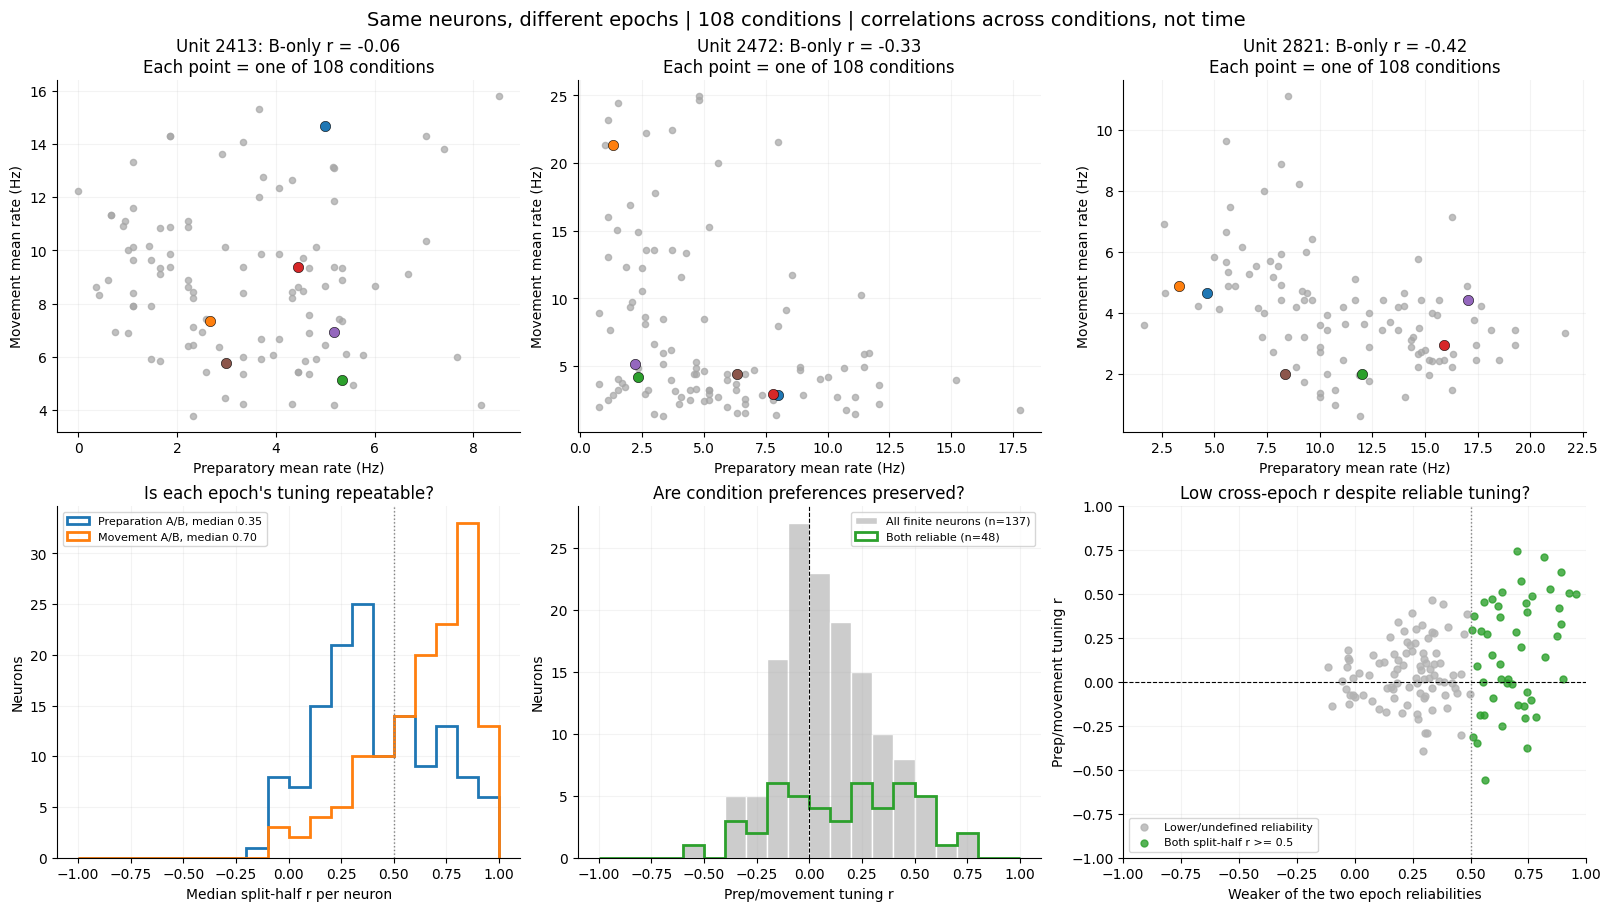

In [19]:
epoch_reliability_threshold = 0.5
epoch_reliability_seeds = list(range(42, 62))
epoch_split_measures = []
epoch_partition_keys = set()
for epoch_seed in epoch_reliability_seeds:
    measures, assignment, _ = compare_epoch_halves(epoch_rates, epoch_trials["condition_id"], epoch_seed)
    epoch_split_measures.append(measures)
    epoch_partition_keys.add(tuple(assignment.index[assignment.eq("A")]))
    if epoch_seed == 42:
        pd.testing.assert_frame_equal(measures, epoch_first_measures)
        pd.testing.assert_series_equal(assignment, epoch_assignment)
assert len(epoch_partition_keys) == len(epoch_reliability_seeds)
epoch_reliability_details = pd.concat(
    epoch_split_measures, keys=epoch_reliability_seeds, names=["seed", "neuron"],
 )
epoch_neuron_results = epoch_reliability_details.groupby(level="neuron").median()
epoch_neuron_results["Prep/move, matched trials"] = condition_curve_correlations(
    epoch_condition_means["preparation"], epoch_condition_means["movement"],
 )
epoch_disjoint_long = epoch_reliability_details[["Prep A / move B", "Prep B / move A"]].stack(dropna=False)
epoch_neuron_results["Prep/move, disjoint halves"] = epoch_disjoint_long.groupby(level="neuron").median()
epoch_neuron_results["Minimum epoch reliability"] = epoch_neuron_results[["Preparation A/B", "Movement A/B"]].min(
    axis=1, skipna=False,
 )
epoch_neuron_results["Both reliable"] = epoch_neuron_results["Minimum epoch reliability"].ge(epoch_reliability_threshold)
epoch_neuron_results["Prep range Hz"] = epoch_condition_means["preparation"].apply(np.ptp)
epoch_neuron_results["Movement range Hz"] = epoch_condition_means["movement"].apply(np.ptp)
epoch_measure_columns = [
    "Preparation A/B", "Movement A/B", "Prep/move, matched trials", "Prep/move, disjoint halves",
]
epoch_summary = epoch_neuron_results[epoch_measure_columns].agg(["count", "median", "mean", "min", "max"]).T
epoch_reliable_summary = epoch_neuron_results.loc[
    epoch_neuron_results["Both reliable"], ["Prep/move, matched trials", "Prep/move, disjoint halves"],
].agg(["count", "median", "mean", "min", "max"]).T
print("Across-neuron summary; reliability and disjoint-half entries summarize 20 partitions per neuron:")
print(epoch_summary.to_string(float_format=lambda value: f"{value:.3f}"))
print(f"\nExploratory reliability screen: both epoch split-half medians >= {epoch_reliability_threshold}; not a significance test.")
print(epoch_reliable_summary.to_string(float_format=lambda value: f"{value:.3f}"))
print("\nUndefined coefficients across all 20 splits (left as NaN):")
print(epoch_reliability_details.isna().sum().to_string())
epoch_example_b_correlations = condition_curve_correlations(
    epoch_half_means[("preparation", "B")], epoch_half_means[("movement", "B")],
 )
print("\nPreselected examples; full-condition B-only cross-epoch correlation:")
print(epoch_example_b_correlations.loc[epoch_example_units].to_string(float_format=lambda value: f"{value:.3f}"))

epoch_comparison_figure, epoch_comparison_axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
for column, unit_id in enumerate(epoch_example_units):
    axis = epoch_comparison_axes[0, column]
    prep_means = epoch_half_means[("preparation", "B")][unit_id]
    movement_means = epoch_half_means[("movement", "B")][unit_id]
    axis.scatter(prep_means, movement_means, color="0.65", s=20, alpha=0.7)
    for condition_id in epoch_example_conditions:
        axis.scatter(
            prep_means.loc[condition_id], movement_means.loc[condition_id],
            color=epoch_colors[condition_id], edgecolors="black", linewidths=0.4, s=55, zorder=3,
        )
    axis.set(
        xlabel="Preparatory mean rate (Hz)", ylabel="Movement mean rate (Hz)",
        title=f"Unit {unit_id}: B-only r = {epoch_example_b_correlations.loc[unit_id]:.2f}\nEach point = one of 108 conditions",
    )

correlation_bins = np.linspace(-1, 1, 21)
reliability_axis = epoch_comparison_axes[1, 0]
for measure, color in [("Preparation A/B", "tab:blue"), ("Movement A/B", "tab:orange")]:
    values = epoch_neuron_results[measure].dropna()
    reliability_axis.hist(values, bins=correlation_bins, histtype="step", linewidth=2, color=color,
                          label=f"{measure}, median {values.median():.2f}")
reliability_axis.axvline(epoch_reliability_threshold, color="0.5", linestyle=":", linewidth=1)
reliability_axis.set(xlabel="Median split-half r per neuron", ylabel="Neurons", title="Is each epoch's tuning repeatable?")
reliability_axis.legend(fontsize=8)

cross_axis = epoch_comparison_axes[1, 1]
all_cross = epoch_neuron_results["Prep/move, matched trials"].dropna()
reliable_cross = epoch_neuron_results.loc[epoch_neuron_results["Both reliable"], "Prep/move, matched trials"].dropna()
cross_axis.hist(all_cross, bins=correlation_bins, color="0.8", edgecolor="white",
                label=f"All finite neurons (n={len(all_cross)})")
cross_axis.hist(reliable_cross, bins=correlation_bins, histtype="step", color="tab:green", linewidth=2,
                label=f"Both reliable (n={len(reliable_cross)})")
cross_axis.axvline(0, color="black", linestyle="--", linewidth=0.8)
cross_axis.set(xlabel="Prep/movement tuning r", ylabel="Neurons", title="Are condition preferences preserved?")
cross_axis.legend(fontsize=8)

comparison_axis = epoch_comparison_axes[1, 2]
for selected_flag, color, label in [(False, "0.7", "Lower/undefined reliability"), (True, "tab:green", "Both split-half r >= 0.5")]:
    selected_results = epoch_neuron_results.loc[epoch_neuron_results["Both reliable"].eq(selected_flag)]
    comparison_axis.scatter(
        selected_results["Minimum epoch reliability"], selected_results["Prep/move, matched trials"],
        s=25, color=color, alpha=0.8, label=label,
    )
comparison_axis.axvline(epoch_reliability_threshold, color="0.5", linestyle=":", linewidth=1)
comparison_axis.axhline(0, color="black", linestyle="--", linewidth=0.8)
comparison_axis.set(
    xlim=(-1, 1), ylim=(-1, 1), xlabel="Weaker of the two epoch reliabilities",
    ylabel="Prep/movement tuning r", title="Low cross-epoch r despite reliable tuning?",
 )
comparison_axis.legend(fontsize=8, loc="lower left")
for axis in epoch_comparison_axes.ravel():
    axis.spines[["top", "right"]].set_visible(False)
    axis.grid(alpha=0.15)
epoch_comparison_figure.suptitle(
    "Same neurons, different epochs | 108 conditions | correlations across conditions, not time", fontsize=14,
 )
epoch_comparison_figure.savefig(
    TRAIN_NWB.parents[3] / "assets" / "mcmaze_preparation_movement_correlations.png",
    dpi=150, bbox_inches="tight",
 )
plt.show()

### Preparation/movement results (2026-09-14)

All 1,967 eligible long-delay trials have complete, observed windows in both
epochs: 137 held-in units, 108 maze/version conditions, 14-24 trials per condition
(median 18). No matched quantitative windows were dropped. Raw timestamp
boundary tests and 50 direct-mask checks passed.

| Across-neuron statistic | Median | Mean |
|---|---:|---:|
| Preparation split-half reliability | 0.350 | 0.412 |
| Movement split-half reliability | 0.704 | 0.644 |
| Preparation/movement correlation, all matched trials | 0.050 | 0.089 |
| Preparation/movement correlation, disjoint halves | 0.025 | 0.064 |

Reliability and disjoint-half entries first summarize repeated partitions per
neuron, then summarize across neurons. All coefficients were finite in this
run. Seed 42 reproduced exactly and all 20 partitions were distinct.

**48 neurons pass the exploratory >=0.5 reliability screen in both epochs.**
For them, the matched-trial cross-epoch median is **0.178** (mean 0.164), and
the disjoint-half median is **0.154** (mean 0.142). Their matched-trial
correlations span -0.555 to +0.743: the relationship is heterogeneous, not
uniformly absent or uniformly reversed.

**Interpretation:** full-population cross-epoch agreement is low, but many
preparatory estimates are also noisy. In the reliability-screened subset,
agreement remains modest on average and includes negative values. This argues
against a universal smaller-copy model with preserved condition preferences,
while some neurons do preserve preferences. It does not establish an initial-
state dynamical mechanism or show that kinematics cannot explain the activity.

The three illustration neurons (2413, 2472, 2821) were chosen using A-only
modulation and a fixed random seed, not cross-epoch correlation. Their B-only
correlations across all conditions are -0.057, -0.332, and -0.421. They illustrate
variation but are not representative estimates of the whole population.
The trace plot uses 9-10 independent B trials per displayed condition.

The preparation reliability here is not directly comparable to the earlier
0.835 direction-split result: this analysis uses 108 full conditions instead of
34 direction groups, fewer trials per condition, long-delay trials only, and
different averaging windows. The earlier directional repeatability is not
contradicted by changing condition preferences between epochs.

No cosine model, kinematic encoding model, population decoder, time-resolved
correlation curve, or dynamical model was fitted in these two experiments.
The old static PCA/cosine results remain unrerun.

Saved figures: [aligned traces](../assets/mcmaze_preparation_movement_traces.png)
and [condition-correlation analysis](../assets/mcmaze_preparation_movement_correlations.png).
`epoch_neuron_results` retains per-neuron measures; `epoch_reliability_details`
retains each split's coefficients; `epoch_rates` retains the matched trial rates.